# AgriClimate Intelligence - Quantile Yield Modelling

This notebook represents the model-development and model-selection workflow for annual crop yield prediction. Three crops are modelled separately: `Durum wheat`, `Soft wheat` and `Grain maize`.

Performing a quantile regression allows to have a probabilistic objective instead of simply a point-based prediction/estimation. Q1, Q2 and Q3 represent the 0.25, 0.50 and 0.75 conditional quantiles of yield. Q2 (which is equivalent to the median) is the primary model-selection target, while Q1 and Q3 are retained where useful to assess whether conclusions extend beyond the conditional median.

Because the data are temporal, all model development follows chronological splits. The modelling sequence is deliberately progressive:

1. an historical linear baseline;
2. Sequential Forward Selection (SFS) over historical and climate predictors, to potentially select significative climate features;
3. L1 regularization as a fine-tuning attempt over the linear model;
4. CatBoost as a conventional nonlinear tabular model;
5. outer temporal validation on 2016-2018;
6. TabPFN as a tabular foundation model;
7. temporal robustness checks for the strongest competing specifications.

The development period ends in 2015. The 2016-2018 block is used as validation set, to perform model selection. The 2019-2022 period is never used in either training or validation, its role is to be the true test set, to estimate the final performance of a model whose specification has already been frozen.

The completed SFS search is not rerun because of its computational cost. Its selected feature sets are stored explicitly below and reused consistently throughout the subsequent experiments.

## Setup

The development period is evaluated through three expanding temporal folds:

- train through 2006 → validate on 2007-2009;
- train through 2009 → validate on 2010-2012;
- train through 2012 → validate on 2013-2015.

This preserves the forecasting logic: every validation period is predicted using only observations from previous years.

`SFS_TOL` is the minimum improvement in mean temporal-CV Q2 required before SFS accepts another predictor.

For CatBoost, the two most recent years inside each training window are used only to determine the stopping iteration. The model is then refitted on the complete training window using that number of trees, so the external validation period is never used for fitting or early stopping.


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import tabpfn_client
from tabpfn_client import TabPFNRegressor

from IPython.display import display


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"

# Make the project utilities available when the notebook is executed
# from the notebooks directory.
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from eda_utils import *
from modelling_utils import *

In [2]:
# Development setup shared by all crops and all quantiles.
CUTOFF = 2015
ROLLING_YEARS = 5

CROPS = [
    "Durum wheat",
    "Soft wheat",
    "Grain maize",
]

QUANTILES = {
    "Q1": 0.25,
    "Q2": 0.50,
    "Q3": 0.75,
}

# Expanding temporal folds: every validation block is strictly later than the
# observations used to fit its model.
CV_FOLDS = [
    ("2007-2009", 2007, 2009),
    ("2010-2012", 2010, 2012),
    ("2013-2015", 2013, 2015),
]

# Minimum mean-CV Q2 improvement required by SFS before another feature is kept.
SFS_TOL = 1e-4

# Minimal CatBoost overfitting control.
EARLY_STOPPING_YEARS = 2
EARLY_STOPPING_ROUNDS = 50

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.6g}".format)

DATA_PATH = DATA_DIR / "modelling_data.csv"

## Data preparation

The complete modelling dataset is loaded once and ordered by crop, province and harvest year.

The candidate pool used by SFS contains:

- four historical predictors derived only from previous yields;
- all phase-level climate variables, identified by the `__` separator in their names.

No historical predictor is forced into the selected model: historical and climate variables compete in the same candidate pool. Current-year `area`, `production` and `yield` are never used as predictors by choice.

The linear models keep the original explicit missing-value treatment because `StandardScaler` and `QuantileRegressor` require complete numeric inputs. In parallel, the corresponding non-imputed historical variables are preserved for CatBoost and TabPFN, which can handle missing numerical values natively. This allows the nonlinear models to use missingness directly rather than receiving the zero-filled values required by the linear pipeline. The explicit `yield_lag_1_missing` indicator is retained, so the historical information set changes only in how missing numeric values are represented.

In [3]:
# Load the modelling table and keep a deterministic chronological order inside
# every crop-province series.
data = pd.read_csv(DATA_PATH)

data = (
    data
    .sort_values([
        "crop_name",
        "PROVINCE",
        "harvest_year",
    ])
    .reset_index(drop=True)
)

# Phase-level climate variables are the columns produced by the crop-calendar
# aggregation step and therefore contain the "__" separator.
CLIMATE_FEATURES = [
    column
    for column in data.columns
    if "__" in column
]

# Keep the lag missingness flag for the linear specification.
data["yield_lag_1_missing"] = (
    data["yield_lag_1"]
    .isna()
    .astype(int)
)

data["yield_lag_1_zero_filled"] = (
    data["yield_lag_1"]
    .fillna(0.0)
)

# Preserve the raw rolling histories for models that support NaN values.
data["yield_median_province_rolling_native"] = (
    rolling_history_median(
        data,
        ["crop_name", "PROVINCE"],
        years=ROLLING_YEARS,
    )
)

data["yield_median_region_rolling_native"] = (
    rolling_history_median(
        data,
        ["crop_name", "REGION"],
        years=ROLLING_YEARS,
    )
)

# Linear models use zero-filled versions of the same historical summaries.
data["yield_median_province_rolling"] = (
    data["yield_median_province_rolling_native"]
    .fillna(0.0)
)

data["yield_median_region_rolling"] = (
    data["yield_median_region_rolling_native"]
    .fillna(0.0)
)

HISTORICAL_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "yield_median_region_rolling",
]

# SFS can freely choose between historical and phase-level climate information.
SFS_CANDIDATE_FEATURES = (
    HISTORICAL_FEATURES
    + CLIMATE_FEATURES
)

# Replace only the imputed historical columns when a model supports NaNs.
NATIVE_FEATURE_MAP = {
    "yield_lag_1_zero_filled": "yield_lag_1",
    "yield_median_province_rolling": "yield_median_province_rolling_native",
    "yield_median_region_rolling": "yield_median_region_rolling_native",
}



# Rows without an observed target cannot be used for supervised modelling.
model_data = (
    data
    .dropna(subset=["yield"])
    .copy()
)

# The development/benchmark boundary is fixed before any model comparison.
development_data = (
    model_data[
        model_data["harvest_year"] <= CUTOFF
    ]
    .copy()
)

benchmark_data = (
    model_data[
        model_data["harvest_year"] > CUTOFF
    ]
    .copy()
)

print("Rows used for modelling:", len(model_data))
print(
    "Development years:",
    development_data["harvest_year"].min(),
    "-",
    development_data["harvest_year"].max(),
)
print(
    "Held-out benchmark years:",
    benchmark_data["harvest_year"].min(),
    "-",
    benchmark_data["harvest_year"].max(),
)
print("Historical features:", len(HISTORICAL_FEATURES))
print("Climate features:", len(CLIMATE_FEATURES))
print("SFS candidates:", len(SFS_CANDIDATE_FEATURES))

Rows used for modelling: 7576
Development years: 1995 - 2015
Held-out benchmark years: 2016 - 2022
Historical features: 4
Climate features: 192
SFS candidates: 196


### Quantile regression

Standard regression models usually estimate the **conditional mean** of a target. Quantile regression instead estimates a chosen conditional quantile

\[
Q_{\tau}(Y \mid X),
\]

where $\tau$ identifies the part of the conditional target distribution being modelled.

This is useful when the objective is not only to predict an expected yield but also to describe how the plausible yield distribution changes with the available predictors. In this notebook:

- `Q1` estimates the 25th conditional percentile;
- `Q2` estimates the conditional median;
- `Q3` estimates the 75th conditional percentile.

Quantile regression is trained through the **pinball loss**:

\[
L_{\tau}(y, \hat{y}) =
\begin{cases}
\tau (y-\hat{y}) & \text{if } y \geq \hat{y} \\
(1-\tau)(\hat{y}-y) & \text{if } y < \hat{y}.
\end{cases}
\]

The asymmetric penalty makes the optimal prediction correspond to the requested conditional quantile. At $\tau=0.5$, the loss becomes symmetric and the model estimates the conditional median.

Q2 is therefore used as the primary model-selection objective, while Q1 and Q3 provide complementary information about the lower and upper parts of the conditional yield distribution.

### Linear quantile regression

The first model family assumes that each conditional yield quantile can be represented as a linear combination of the predictors:

\[
Q_{\tau}(Y \mid X)=\beta_{0,\tau}+\beta_{1,\tau}X_1+\dots+\beta_{p,\tau}X_p.
\]

Unlike ordinary least squares, the coefficients are estimated by minimizing pinball loss rather than squared error. A separate coefficient vector is therefore learned for each quantile.

The linear specification provides an appropriate starting point for this analysis for two reasons. First, it offers a parsimonious and interpretable benchmark against which more complex models can be evaluated. Second, with only a few thousand observations per crop, limiting model flexibility reduces the risk of fitting unstable relationships that do not generalize across time.

All numerical predictors are standardized before fitting so that their scales are comparable and the same pipeline can subsequently accommodate regularization.

## Scaled historical baseline

After removing rows without a target, the modelling dataset contains **7,576 observations**. The training set spans **1995-2015**, while the period **2016-2018** has the role of the validation set and the rest (**2019-2022**) is kept aside as the final out-of-time benchmark. The SFS search considers **196 predictors** in total: 4 historical and 192 phase-level climate features.

The first learned benchmark is the historical model, from here on indicated as `H`. It is fitted through exactly the same scaling and quantile-regression pipeline later used for the SFS feature set, so the comparison changes only the predictors and not the estimator or validation procedure.

In [4]:
# Fit the same four-feature historical specification separately for each crop.
baseline_results = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    scores = evaluate_feature_set(
        crop_development,
        HISTORICAL_FEATURES,
        QUANTILES,
        CV_FOLDS,
    )

    baseline_results.append({
        "crop": crop,
        "model": "LinearQR",
        "features": "H",
        **scores,
    })

baseline_results = pd.DataFrame(
    baseline_results
)

# One row per crop keeps Q1, Q2 and Q3 directly comparable.
display(
    baseline_results.set_index([
        "crop",
        "model",
        "features",
    ])
)

,,,Train Q1,Train Q2,Train Q3,CV Q1,CV Q2,CV Q3
crop,model,features,,,,,,
Durum wheat,LinearQR,H,0.203877,0.241653,0.201903,0.206603,0.241013,0.202508
Soft wheat,LinearQR,H,0.215177,0.248214,0.204443,0.233367,0.25635,0.211042
Grain maize,LinearQR,H,0.441069,0.496001,0.421002,0.414412,0.473793,0.416559


## Sequential Forward Selection

Sequential Forward Selection (from here on indicated as SFS) is a **wrapper-based feature-selection procedure** that builds a predictor set iteratively. Starting from an empty set, candidate variables are added one at a time according to the improvement they provide to a chosen validation objective.

In this notebook, SFS is performed **separately for each crop** using the same expanding temporal folds defined above. The selection criterion is Q2 pinball loss, and no predictor is mandatory at the beginning of the search. A feature is therefore retained only when its inclusion improves median-yield prediction on future validation periods rather than simply improving the fit to the observations used for estimation.

SFS is a greedy procedure: once a variable has been added, previous choices are not exhaustively reconsidered. More importantly, the resulting subset is **model-specific**. Here, predictors are selected according to their contribution to linear quantile regression, so the final SFS sets should not be interpreted as the only informative variables in the dataset. Features excluded by SFS may still contain useful information for models able to exploit nonlinear effects or interactions.

The complete search covers 196 candidate predictors and takes several hours to run. It is therefore not repeated in this notebook. The original execution code is preserved in commented form for reproducibility, while the exact crop-specific feature sets returned by the completed search are stored explicitly below and reused in all subsequent experiments.

The notebook thus **recomputes model performance using the selected features, but does not perform a new feature-selection search**. This also allows the same SFS subsets to be compared later with the full feature pool when evaluating nonlinear models.

In [5]:
# Original SFS execution preserved for reproducibility but disabled. Running this
# block would repeat the expensive feature search separately for every crop.
# SFS_SELECTORS = {}
# SFS_SELECTED_FEATURES = {}
# SFS_RESULTS = []
#
# for crop in CROPS:
#     print("=" * 80)
#     print(crop)
#     print("=" * 80)
#
#     crop_development = (
#         development_data[
#             development_data["crop_name"] == crop
#         ]
#         .copy()
#     )
#
#     selector, selected_features = fit_sfs(
#         crop_development,
#         SFS_CANDIDATE_FEATURES,
#         QUANTILES["Q2"],
#         SFS_TOL,
#         CV_FOLDS,
#     )
#
#     SFS_SELECTORS[crop] = selector
#     SFS_SELECTED_FEATURES[crop] = selected_features
#
#     scores = evaluate_feature_set(
#         crop_development,
#         selected_features,
#         QUANTILES,
#         CV_FOLDS,
#     )
#
#     SFS_RESULTS.append({
#         "crop": crop,
#         "model": "LinearQR",
#         "features": "SFS",
#         "n_features": len(selected_features),
#         **scores,
#     })
#
#     print("Selected features:", len(selected_features))
#     display(selected_feature_table(selected_features, HISTORICAL_FEATURES))

# Exact feature sets obtained from the completed SFS run are stored below.

In [6]:
# Selected feature set returned by SFS for durum wheat.
DURUM_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "EXTREME_HEAT_AREA_FRACTION_MAX__planting_early_vegetative",
    "EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive",
    "EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive",
    "EXTREME_WIND_AREA_WHEN_PRESENT__planting_early_vegetative",
    "DAYS_HOT_35_ANY_AREA__vegetative_reproductive",
    "MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__planting_early_vegetative",
    "MAX_CONSECUTIVE_FROST_10PCT_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive",
]

# Selected feature set returned by SFS for soft wheat.
SOFT_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "TEMPERATURE_MAX_MONTH__vegetative_reproductive",
    "TEMPERATURE_MIN_MONTH__vegetative_reproductive",
    "VAPOURPRESSURE_AVG_MONTH__ripening_harvest",
    "TEMPERATURE_SPATIAL_STD_AVG__vegetative_reproductive",
    "WET_AREA_WHEN_PRESENT__planting_early_vegetative",
    "DAYS_VERY_EXTREME_RAIN__ripening_harvest",
    "EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive",
    "EXTREME_COLD_AREA_FRACTION_AVG__planting_early_vegetative",
    "DAYS_FROST_ANY_AREA__planting_early_vegetative",
    "DAYS_HOT_35_ANY_AREA__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_COLD_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_VERY_EXTREME_RAIN_DAYS__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_WIND_DAYS__vegetative_reproductive",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__ripening_harvest",
    "MAX_CONSECUTIVE_HOT_30_10PCT_DAYS__vegetative_reproductive",
]

# Selected feature set returned by SFS for grain maize.
MAIZE_SFS_FEATURES = [
    "yield_lag_1_zero_filled",
    "yield_lag_1_missing",
    "yield_median_province_rolling",
    "yield_median_region_rolling",
    "TEMPERATURE_MIN_MONTH__planting_early_vegetative",
    "VAPOURPRESSURE_AVG_MONTH__planting_early_vegetative",
    "ET0_DAILY_AVG__vegetative_reproductive",
    "RADIATION_DAILY_AVG__ripening_harvest",
    "PRECIPITATION_TOTAL_MONTH__vegetative_reproductive",
    "WET_DAYS_SPATIAL__ripening_harvest",
    "DRY_DAYS_ALL_CELLS__vegetative_reproductive",
    "WET_AREA_FRACTION_AVG__vegetative_reproductive",
    "DAYS_RAIN_20__planting_early_vegetative",
    "DAYS_RAIN_20__vegetative_reproductive",
    "DAYS_RAIN_50__planting_early_vegetative",
    "RAIN_20_AREA_FRACTION_MAX__vegetative_reproductive",
    "DAYS_EXTREME_HEAT__vegetative_reproductive",
    "EXTREME_COLD_AREA_WHEN_PRESENT__ripening_harvest",
    "EXTREME_WIND_AREA_FRACTION_AVG__vegetative_reproductive",
    "EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive",
    "DAYS_HOT_30_ANY_AREA__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_HEAT_DAYS__ripening_harvest",
    "MAX_CONSECUTIVE_EXTREME_COLD_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative",
    "MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__ripening_harvest",
]

SFS_SELECTED_FEATURES = {
    "Durum wheat": DURUM_SFS_FEATURES,
    "Soft wheat": SOFT_SFS_FEATURES,
    "Grain maize": MAIZE_SFS_FEATURES,
}

# Recompute only the evaluation of the fixed feature sets. This is much faster
# than SFS itself and leaves the selected predictors unchanged.
SFS_RESULTS = []

# Evaluate each stored feature set with the same pipeline and temporal folds used
# for the historical baseline.
for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    selected_features = SFS_SELECTED_FEATURES[crop]

    scores = evaluate_feature_set(
        crop_development,
        selected_features,
        QUANTILES,
        CV_FOLDS,
    )

    SFS_RESULTS.append({
        "crop": crop,
        "model": "LinearQR",
        "features": "SFS",
        "n_features": len(selected_features),
        **scores,
    })

    print("=" * 80)
    print(crop)
    print("=" * 80)
    print("Selected features:", len(selected_features))

    display(
        selected_feature_table(
            selected_features,
            HISTORICAL_FEATURES,
        )
    )

Durum wheat
Selected features: 12


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,EXTREME_HEAT_AREA_FRACTION_MAX__planting_early_vegetative,climate,planting_early_vegetative
4,EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive,climate,vegetative_reproductive
5,EXTREME_WIND_AREA_FRACTION_MAX__vegetative_reproductive,climate,vegetative_reproductive
6,EXTREME_WIND_AREA_WHEN_PRESENT__planting_early_vegetative,climate,planting_early_vegetative
7,DAYS_HOT_35_ANY_AREA__vegetative_reproductive,climate,vegetative_reproductive
8,MAX_CONSECUTIVE_EXTREME_RAIN_DAYS__planting_early_vegetative,climate,planting_early_vegetative
9,MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN__planting_early_vegetative,climate,planting_early_vegetative


Soft wheat
Selected features: 18


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,TEMPERATURE_MAX_MONTH__vegetative_reproductive,climate,vegetative_reproductive
4,TEMPERATURE_MIN_MONTH__vegetative_reproductive,climate,vegetative_reproductive
5,VAPOURPRESSURE_AVG_MONTH__ripening_harvest,climate,ripening_harvest
6,TEMPERATURE_SPATIAL_STD_AVG__vegetative_reproductive,climate,vegetative_reproductive
7,WET_AREA_WHEN_PRESENT__planting_early_vegetative,climate,planting_early_vegetative
8,DAYS_VERY_EXTREME_RAIN__ripening_harvest,climate,ripening_harvest
9,EXTREME_HEAT_AREA_WHEN_PRESENT__vegetative_reproductive,climate,vegetative_reproductive


Grain maize
Selected features: 25


,feature,source,phase
0,yield_lag_1_zero_filled,historical,None
1,yield_lag_1_missing,historical,None
2,yield_median_province_rolling,historical,None
3,yield_median_region_rolling,historical,None
4,TEMPERATURE_MIN_MONTH__planting_early_vegetative,climate,planting_early_vegetative
5,VAPOURPRESSURE_AVG_MONTH__planting_early_vegetative,climate,planting_early_vegetative
6,ET0_DAILY_AVG__vegetative_reproductive,climate,vegetative_reproductive
7,RADIATION_DAILY_AVG__ripening_harvest,climate,ripening_harvest
8,PRECIPITATION_TOTAL_MONTH__vegetative_reproductive,climate,vegetative_reproductive
9,WET_DAYS_SPATIAL__ripening_harvest,climate,ripening_harvest


## Baseline versus SFS

The following table compares the historical baseline `H` with the fixed SFS feature sets over the development data. 
(A lower pinball loss is better)

The main quantities of interest are the mean temporal-CV losses at Q1, Q2 and Q3 and the additional number of predictors required by SFS. Train and CV values are shown together, but their difference should not be read as a classical random-split overfitting gap because they refer to different temporal samples and training windows.

In [7]:
# Combine the two specifications into a single crop-by-model comparison table.
sfs_results = pd.DataFrame(
    SFS_RESULTS
)

comparison = pd.concat(
    [
        baseline_results.assign(
            n_features=len(HISTORICAL_FEATURES)
        ),
        sfs_results,
    ],
    ignore_index=True,
)

comparison = comparison[
    [
        "crop",
        "model",
        "features",
        "n_features",
        "Train Q1",
        "CV Q1",
        "Train Q2",
        "CV Q2",
        "Train Q3",
        "CV Q3",
    ]
]

display(
    comparison.set_index([
        "crop",
        "model",
        "features",
    ])
)

,,,n_features,Train Q1,CV Q1,Train Q2,CV Q2,Train Q3,CV Q3
crop,model,features,,,,,,,
Durum wheat,LinearQR,H,4,0.203877,0.206603,0.241653,0.241013,0.201903,0.202508
Soft wheat,LinearQR,H,4,0.215177,0.233367,0.248214,0.25635,0.204443,0.211042
Grain maize,LinearQR,H,4,0.441069,0.414412,0.496001,0.473793,0.421002,0.416559
Durum wheat,LinearQR,SFS,12,0.19815,0.203725,0.236968,0.233904,0.198888,0.200669
Soft wheat,LinearQR,SFS,18,0.206807,0.224383,0.24033,0.244496,0.196539,0.203132
Grain maize,LinearQR,SFS,25,0.406718,0.396601,0.474964,0.450262,0.403291,0.401842


### Development comparison

SFS improves mean temporal-CV Q2 for all three crops:

* **Durum wheat:** 0.2410 → 0.2339, about **3.0%** lower loss;
* **Soft wheat:** 0.2564 → 0.2445, about **4.6%** lower loss;
* **Grain maize:** 0.4738 → 0.4503, about **5.0%** lower loss.

Mean CV loss also decreases at Q1 and Q3 for every crop. The improvement therefore is not limited to the median model, although its temporal consistency still needs to be checked fold by fold.

The gain comes with a clear increase in complexity: SFS retains 12 predictors for durum wheat, 18 for soft wheat and 25 for grain maize, compared with 4 historical predictors in `H`. This makes temporal stability and the benchmark on the validation set particularly important before preferring the larger specifications.

## What did SFS retain?

The selected sets preserve most of the historical information but also add a substantial climate component.

For **durum wheat** and **soft wheat**, SFS keeps three of the four historical predictors and drops only the rolling regional median. For **grain maize**, all four historical predictors are retained. Climate variables therefore complement rather than replace recent yield history.

The climate composition differs across crops. 
- **Durum wheat** is dominated by heat, wind, frost, dry-spell and extreme-rain indicators;
- **soft wheat** combines temperature, vapour pressure, wetness and several extreme-event measures;
- **grain maize** retains a broader mix including temperature, vapour pressure, evapotranspiration, radiation, precipitation, wet/dry conditions and extremes.

The phase suffix is reported because the same physical phenomenon can have a different role across crop stages.

In [8]:
# Count how much historical and climate information survives SFS for each crop.
selection_summary = []

for crop in CROPS:
    selected_features = SFS_SELECTED_FEATURES[crop]

    selected_historical = [
        feature
        for feature in selected_features
        if feature in HISTORICAL_FEATURES
    ]

    selected_climate = [
        feature
        for feature in selected_features
        if feature in CLIMATE_FEATURES
    ]

    selection_summary.append({
        "crop": crop,
        "total selected": len(selected_features),
        "historical selected": len(selected_historical),
        "climate selected": len(selected_climate),
        "historical retained": ", ".join(selected_historical),
    })

display(
    pd.DataFrame(selection_summary)
    .set_index("crop")
)

,total selected,historical selected,climate selected,historical retained
crop,,,,
Durum wheat,12,3,9,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling"
Soft wheat,18,3,15,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling"
Grain maize,25,4,21,"yield_lag_1_zero_filled, yield_lag_1_missing, yield_median_province_rolling, yield_median_region_rolling"


## Temporal stability of the linear models

Mean cross-validation performance can hide changes between validation periods. The next analysis therefore evaluates `LinearQR H` and `LinearQR SFS` separately in each expanding temporal fold.

The key question is not whether one period is absolutely easier or harder than another, but whether the **relative advantage of SFS over H remains visible as validation moves forward in time**.

Q1, Q2 and Q3 are retained, while Q2 remains the primary comparison because it drove SFS.

In [9]:
# Store one row for every crop, fold, feature set and quantile so the same result
# table can support both absolute and relative stability diagnostics.
fold_results = []

for crop in CROPS:
    crop_development = development_data[
        development_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": HISTORICAL_FEATURES,
        "SFS": SFS_SELECTED_FEATURES[crop],
    }

    for fold_order, (fold_name, validation_start, validation_end) in enumerate(
        CV_FOLDS,
        start=1,
    ):
        train = crop_development[
            crop_development["harvest_year"] < validation_start
        ]

        validation = crop_development[
            crop_development["harvest_year"].between(
                validation_start,
                validation_end,
            )
        ]

        # Refit both specifications from scratch within the same fold.
        for feature_label, features in feature_sets.items():
            for quantile_name, quantile in QUANTILES.items():
                model = make_linear_pipeline(quantile)

                model.fit(
                    train[features],
                    train["yield"],
                )

                prediction = model.predict(
                    validation[features]
                )

                fold_results.append({
                    "crop": crop,
                    "fold_order": fold_order,
                    "fold": fold_name,
                    "features": feature_label,
                    "quantile": quantile_name,
                    "pinball": pinball(
                        validation["yield"],
                        prediction,
                        quantile,
                    ),
                })

fold_results = pd.DataFrame(fold_results)

### Q2 (median) performance by fold

The table reports median-model pinball loss separately for each validation period. A lower value is better.

Absolute losses vary across folds, especially for grain maize, so comparisons should be made primarily between `H` and `SFS` **within the same period**.

In [10]:
# Reshape Q2 losses so H and SFS can be compared directly across validation folds.
q2_fold_table = (
    fold_results[
        fold_results["quantile"] == "Q2"
    ]
    .pivot_table(
        index=["crop", "features"],
        columns="fold",
        values="pinball",
    )
)

display(q2_fold_table)

fold                  2007-2009  2010-2012  2013-2015
crop        features                                 
Durum wheat H          0.232637   0.257835   0.232568
            SFS        0.223453   0.252315   0.225944
Grain maize H          0.392866   0.478474   0.550039
            SFS        0.373839   0.456746     0.5202
Soft wheat  H          0.241806   0.299519   0.227726
            SFS        0.226798   0.283949   0.222743

### Relative SFS advantage by fold

At Q2, SFS has lower loss in **all nine crop-fold comparisons**.

* **Durum wheat:** the improvement is 3.95%, 2.14% and 2.85% across the three folds. The gain is modest but does not disappear in the latest period.
* **Soft wheat:** the improvement decreases from 6.21% to 5.20% and then to 2.19%. SFS still wins in 2013-2015, but the advantage clearly narrows.
* **Grain maize:** the improvement remains close to 5% throughout (4.84%, 4.54%, 5.42%), giving the most stable Q2 result.

The table below expresses the same comparison directly. `SFS - H < 0` and `SFS improvement % > 0` both indicate an SFS advantage.

In [11]:
# Put H and SFS on the same row and express the SFS advantage both as an
# absolute pinball-loss difference and as a percentage of the H loss.
q2_relative = (
    fold_results[
        fold_results["quantile"] == "Q2"
    ]
    .pivot_table(
        index=[
            "crop",
            "fold_order",
            "fold",
        ],
        columns="features",
        values="pinball",
    )
    .reset_index()
)

q2_relative["SFS - H"] = (
    q2_relative["SFS"]
    - q2_relative["H"]
)

q2_relative["SFS improvement %"] = (
    (q2_relative["H"] - q2_relative["SFS"])
    / q2_relative["H"]
    * 100
)

q2_relative["winner"] = np.where(
    q2_relative["SFS"] < q2_relative["H"],
    "SFS",
    "H",
)

display(
    q2_relative
    .sort_values([
        "crop",
        "fold_order",
    ])
    [
        [
            "crop",
            "fold",
            "H",
            "SFS",
            "SFS - H",
            "SFS improvement %",
            "winner",
        ]
    ]
    .set_index([
        "crop",
        "fold",
    ])
)

features                     H      SFS     SFS - H  SFS improvement % winner
crop        fold                                                             
Durum wheat 2007-2009 0.232637 0.223453 -0.00918385            3.94772    SFS
            2010-2012 0.257835 0.252315 -0.00552005            2.14092    SFS
            2013-2015 0.232568 0.225944 -0.00662415            2.84827    SFS
Grain maize 2007-2009 0.392866 0.373839  -0.0190267            4.84306    SFS
            2010-2012 0.478474 0.456746  -0.0217275            4.54101    SFS
            2013-2015 0.550039   0.5202  -0.0298385             5.4248    SFS
Soft wheat  2007-2009 0.241806 0.226798  -0.0150081            6.20666    SFS
            2010-2012 0.299519 0.283949  -0.0155703            5.19845    SFS
            2013-2015 0.227726 0.222743 -0.00498333             2.1883    SFS

### Temporal stability summary

The summary condenses the Q2 comparison into the mean loss, number of folds "won" and change between the first and latest validation periods.

All three crops are won by SFS in all three Q2 folds. The first-to-last change confirms the different stability profiles already visible above: **-1.10 percentage points** for durum wheat, **-4.02 points** for soft wheat and **+0.58 points** for grain maize.

With only three folds these changes are, of course, only descriptive diagnostics: in particular, durum wheat does not show a monotonic decline because the improvement partially recovers in the final fold.

In [12]:
# Summarize how the Q2 advantage changes between the first and the latest fold.
stability_rows = []

for crop in CROPS:
    crop_rows = (
        q2_relative[
            q2_relative["crop"] == crop
        ]
        .sort_values("fold_order")
    )

    stability_rows.append({
        "crop": crop,
        "mean H Q2": crop_rows["H"].mean(),
        "mean SFS Q2": crop_rows["SFS"].mean(),
        "SFS folds won": (crop_rows["winner"] == "SFS").sum(),
        "first-fold SFS improvement %": crop_rows["SFS improvement %"].iloc[0],
        "latest-fold SFS improvement %": crop_rows["SFS improvement %"].iloc[-1],
        "change first-to-last": (
            crop_rows["SFS improvement %"].iloc[-1]
            - crop_rows["SFS improvement %"].iloc[0]
        ),
        "latest-fold winner": crop_rows["winner"].iloc[-1],
    })

stability_summary = pd.DataFrame(
    stability_rows
)

display(
    stability_summary.set_index("crop")
)

,mean H Q2,mean SFS Q2,SFS folds won,first-fold SFS improvement %,latest-fold SFS improvement %,change first-to-last,latest-fold winner
crop,,,,,,,
Durum wheat,0.241013,0.233904,3,3.94772,2.84827,-1.09946,SFS
Soft wheat,0.25635,0.244496,3,6.20666,2.1883,-4.01837,SFS
Grain maize,0.473793,0.450262,3,4.84306,5.4248,0.581741,SFS


### Q1 and Q3 stability

Q2 is consistently favourable to SFS, but the tail quantiles are less uniform.

- For **durum wheat**, `H` is better at Q1 in 2013-2015 and at Q3 in 2007-2009.
- For **soft wheat**, `H` becomes better at Q1 in 2013-2015, while Q3 remains favourable to SFS, with the first fold essentially tied.
- **Grain maize is the only crop for which SFS wins every fold at Q1, Q2 and Q3**, although some tail improvements are small.

This check therefore strengthens the case for maize, while suggesting more caution for the two wheat crops: their median improvement is stable in sign, but not every part of the conditional yield distribution benefits in every period.

In [13]:
# Repeat the relative H-versus-SFS calculation for all three quantiles. This
# checks whether the median result is also representative of the lower and upper
# conditional yield distributions.
quantile_relative = (
    fold_results
    .pivot_table(
        index=[
            "crop",
            "fold_order",
            "fold",
            "quantile",
        ],
        columns="features",
        values="pinball",
    )
    .reset_index()
)

quantile_relative["SFS - H"] = (
    quantile_relative["SFS"]
    - quantile_relative["H"]
)

quantile_relative["SFS improvement %"] = (
    (quantile_relative["H"] - quantile_relative["SFS"])
    / quantile_relative["H"]
    * 100
)

quantile_relative["winner"] = np.where(
    quantile_relative["SFS"] < quantile_relative["H"],
    "SFS",
    "H",
)

display(
    quantile_relative
    .sort_values([
        "crop",
        "quantile",
        "fold_order",
    ])
    [
        [
            "crop",
            "fold",
            "quantile",
            "H",
            "SFS",
            "SFS - H",
            "SFS improvement %",
            "winner",
        ]
    ]
    .set_index([
        "crop",
        "quantile",
        "fold",
    ])
)

features                              H      SFS      SFS - H  SFS improvement % winner
crop        quantile fold                                                              
Durum wheat Q1       2007-2009 0.207388 0.198277   -0.0091102            4.39284    SFS
                     2010-2012 0.209815 0.207472   -0.0023432            1.11679    SFS
                     2013-2015 0.202607 0.205425   0.00281775           -1.39075      H
            Q2       2007-2009 0.232637 0.223453  -0.00918385            3.94772    SFS
                     2010-2012 0.257835 0.252315  -0.00552005            2.14092    SFS
                     2013-2015 0.232568 0.225944  -0.00662415            2.84827    SFS
            Q3       2007-2009 0.181952 0.183663   0.00171104          -0.940383      H
                     2010-2012  0.23116 0.226218  -0.00494185            2.13785    SFS
                     2013-2015 0.194412 0.192127  -0.00228485            1.17526    SFS
Grain maize Q1       2007-2009 0.354364 0.344735  -0.00962947             2.7174    SFS
                     2010-2012 0.466368 0.425979   -0.0403892            8.66037    SFS
                     2013-2015 0.422504 0.419088  -0.00341622           0.808565    SFS
            Q2       2007-2009 0.392866 0.373839   -0.0190267            4.84306    SFS
                     2010-2012 0.478474 0.456746   -0.0217275            4.54101    SFS
                     2013-2015 0.550039   0.5202   -0.0298385             5.4248    SFS
            Q3       2007-2009 0.342429 0.342042 -0.000386759           0.112946    SFS
                     2010-2012 0.379903 0.377713  -0.00218994           0.576446    SFS
                     2013-2015 0.527344 0.485772   -0.0415725            7.88337    SFS
Soft wheat  Q1       2007-2009 0.219237 0.202791   -0.0164456            7.50129    SFS
                     2010-2012 0.270643   0.2548   -0.0158433            5.85394    SFS
                     2013-2015 0.210221 0.215558   0.00533709            -2.5388      H
            Q2       2007-2009 0.241806 0.226798   -0.0150081            6.20666    SFS
                     2010-2012 0.299519 0.283949   -0.0155703            5.19845    SFS
                     2013-2015 0.227726 0.222743  -0.00498333             2.1883    SFS
            Q3       2007-2009 0.196634 0.196629 -5.30987e-06         0.00270038    SFS
                     2010-2012 0.249829 0.231267   -0.0185617            7.42975    SFS
                     2013-2015 0.186662   0.1815  -0.00516117            2.76499    SFS

### Visual check of Q2 over time

The plots below show the absolute Q2 loss of `H` and `SFS` in each validation period using the same visual style adopted in the project EDA.

They should be read together with the relative tables. Parallel movements mainly reflect changes in period difficulty; convergence of the lines indicates that the SFS advantage is becoming smaller. **This is especially visible for soft wheat in the latest fold.**

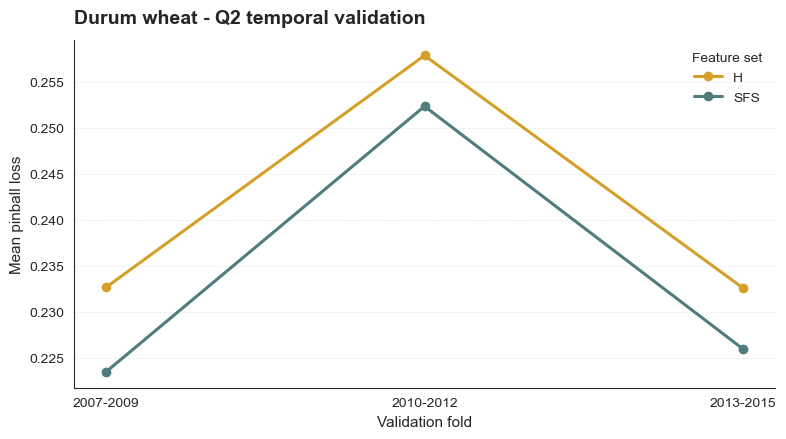

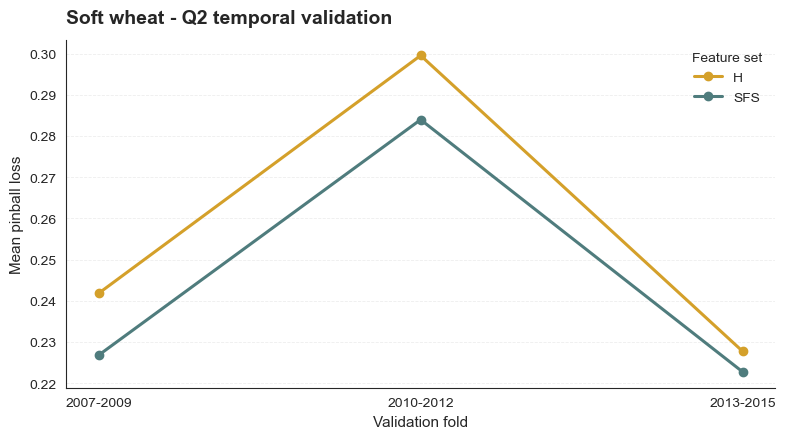

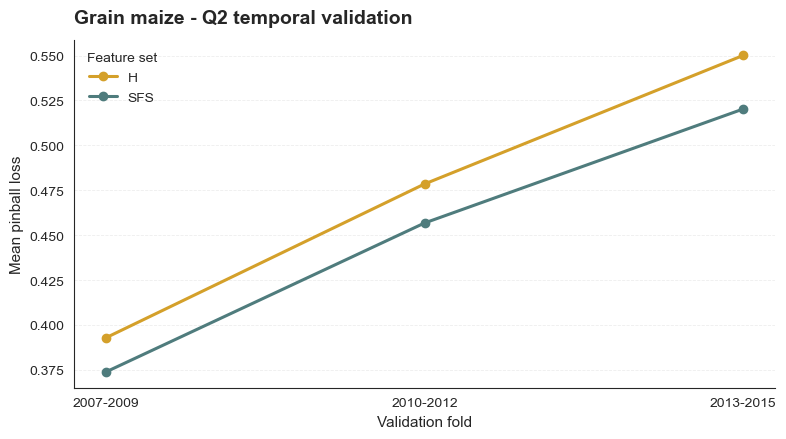

In [14]:
# Plot Q2 losses with the same gold/teal palette and minimal styling used in the
# rest of the project. Each crop keeps its own y scale because absolute pinball
# loss differs substantially between wheat and maize.
set_plot_style()

for crop in CROPS:
    plot_data = (
        fold_results[
            (fold_results["crop"] == crop)
            & (fold_results["quantile"] == "Q2")
        ]
        .pivot(
            index="fold_order",
            columns="features",
            values="pinball",
        )
        .sort_index()
    )

    fold_labels = [
        fold_name
        for fold_name, _, _ in CV_FOLDS
    ]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        plot_data.index,
        plot_data["H"],
        marker="o",
        linewidth=2.2,
        color=GOLD,
        label="H",
    )
    ax.plot(
        plot_data.index,
        plot_data["SFS"],
        marker="o",
        linewidth=2.2,
        color=TEAL,
        label="SFS",
    )

    ax.set_title(f"{crop} - Q2 temporal validation", loc="left")
    ax.set_xlabel("Validation fold")
    ax.set_ylabel("Mean pinball loss")
    ax.set_xticks(range(1, len(fold_labels) + 1))
    ax.set_xticklabels(fold_labels)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend(title="Feature set")

    fig.tight_layout()
    plt.show()

## Interpretations

The development evidence, so far, does **not** support discarding climate features from the linear quantile models. SFS improves mean Q2 loss for every crop and, more importantly, remains better than the historical baseline in every Q2 validation fold. The strength of that evidence is nevertheless crop dependent.

- **Grain maize** provides the clearest case for carrying SFS forward. Its mean Q2 improvement is about 5%, the advantage is stable across the three folds, and SFS also wins every Q1 and Q3 fold. The main counterweight is complexity: the selected model uses 25 predictors.

- **Soft wheat** also benefits from SFS on mean Q2 and in every Q2 fold, but the relative advantage falls from 6.2% in 2007-2009 to 2.2% in 2013-2015. The latest Q1 fold already favours `H`. Climate information therefore appears useful, but its incremental contribution is less temporally robust than for maize.

- **Durum wheat** shows a smaller mean Q2 improvement of about 3%. SFS still wins all three Q2 folds, so there is no development-period reversal at the median, but Q1 and Q3 each contain one fold favouring `H`. The larger feature set should therefore be treated as a promising challenger rather than an automatic replacement for the historical specification.

A final methodological caution remains: SFS was optimized using these same development folds, so the fold-level analysis is mainly a **stability diagnostic of the selected solution**. The later validation period is therefore required to determine whether these development-period gains persist outside the folds used during feature selection.

## L1 (Lasso) regularization of the linear SFS models

The SFS models introduce a larger number of predictors than the historical baseline. While this can improve predictive flexibility, it can also increase estimation variance, particularly when several climate variables contain overlapping information.

**L1 (Lasso) regularization** addresses this problem by adding a penalty proportional to the absolute magnitude of the model coefficients:

\[
\text{Pinball Loss} + \alpha \sum_j |\beta_j|.
\]

As $\alpha$ increases, weak coefficients are progressively shrunk towards zero and sufficiently strong regularization can produce a sparser model. Since all predictors are already standardized inside the modelling pipeline, the penalty is applied on comparable feature scales.

Here L1 regularization is used as a **sensitivity check** on the crop-specific SFS models rather than as a new feature-selection strategy (this mention is needed because Lasso regularization is sometimes used to nullify the contribution of less informative features in a model). The four-feature historical baseline is kept unchanged, while the larger SFS specifications are tested to determine whether additional coefficient shrinkage improves their temporal stability.

For each crop:

- `alpha` is selected using mean temporal-CV Q2 pinball loss over the same three expanding folds used above;
- `alpha = 0` is included, allowing the search to conclude explicitly that regularization provides no improvement;
- when multiple values achieve effectively equivalent Q2 performance, the larger `alpha` is preferred as the more regularized solution;
- the selected crop-specific `alpha` is then reused for Q1 and Q3 rather than tuning each quantile independently.

This deliberately narrow experiment tests whether the selected linear specification benefits materially from regularization before introducing more flexible nonlinear model families.

In [15]:
# Candidate L1 strengths on the standardized SFS predictors. The grid is
# deliberately compact: the purpose is a sensitivity check, not a large search.
L1_ALPHAS = [
    0.0,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
]

# If two alpha values are practically tied on mean Q2 CV loss, prefer the more
# regularized solution. The tolerance is kept on the same scale as the SFS
# stopping tolerance used earlier in the notebook.
L1_SELECTION_TOL = SFS_TOL

### Q2 regularization search

The search below reports three complementary quantities:

* mean Q2 loss across the temporal folds, which drives the choice of `alpha`;
* the standard deviation of the three fold losses, as a descriptive stability indicator;
* the number of non-zero Q2 coefficients after fitting the model on the complete development period.

The coefficient count is useful because an L1 penalty can improve the model either by reducing validation loss or by reaching essentially the same loss with a sparser specification.

In [16]:
# Search one crop-specific alpha on the SFS feature set using Q2 only.
l1_search_rows = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    features = SFS_SELECTED_FEATURES[crop]

    for alpha in L1_ALPHAS:
        fold_scores = q2_l1_cv_scores(
            crop_development,
            features,
            alpha,
            QUANTILES["Q2"],
            CV_FOLDS,
        )

        # Fit once on the full development period only to inspect how much
        # sparsity the penalty induces. This fit is not used to score CV.
        full_model = make_regularized_linear_pipeline(
            QUANTILES["Q2"],
            alpha,
        )

        full_model.fit(
            crop_development[features],
            crop_development["yield"],
        )

        coefficients = full_model.named_steps["model"].coef_
        nonzero_coefficients = np.sum(
            np.abs(coefficients) > 1e-8
        )

        l1_search_rows.append({
            "crop": crop,
            "alpha": alpha,
            "CV Q2": fold_scores["pinball"].mean(),
            "fold std Q2": fold_scores["pinball"].std(ddof=0),
            "non-zero coefficients": nonzero_coefficients,
            "total coefficients": len(coefficients),
        })

In [17]:
l1_search = pd.DataFrame(l1_search_rows)

# Apply the same selection rule crop by crop.
l1_selected_rows = []

for crop in CROPS:
    crop_search = l1_search[
        l1_search["crop"] == crop
    ].copy()

    selected = select_l1_alpha(crop_search, L1_SELECTION_TOL)
    l1_selected_rows.append(selected.to_dict())

l1_selected = pd.DataFrame(l1_selected_rows)

L1_BEST_ALPHA = dict(zip(
    l1_selected["crop"],
    l1_selected["alpha"],
))

print("Selected alpha by crop:")
display(
    l1_selected
    .set_index("crop")
)

print("\nComplete search:")
display(
    l1_search
    .sort_values(["crop", "alpha"])
    .set_index(["crop", "alpha"])
)

Selected alpha by crop:


,alpha,CV Q2,fold std Q2,non-zero coefficients,total coefficients
crop,,,,,
Durum wheat,0.001,0.233818,0.013023,12,12
Soft wheat,0.0001,0.244594,0.0280152,18,18
Grain maize,0.0003,0.450116,0.0599294,24,25



Complete search:


CV Q2  fold std Q2  non-zero coefficients  total coefficients
crop        alpha                                                                  
Durum wheat 0      0.233904    0.0130584                     12                  12
            0.0001 0.233904    0.0130581                     12                  12
            0.0003  0.23391    0.0130493                     12                  12
            0.001  0.233818     0.013023                     12                  12
            0.003  0.233959    0.0122485                     12                  12
            0.01   0.234414    0.0122193                     11                  12
            0.03    0.23466    0.0121315                      8                  12
            0.1    0.271876    0.0113316                      4                  12
Grain maize 0      0.450262    0.0599273                     25                  25
            0.0001  0.45013    0.0599132                     25                  25
            0.0003 0.450116    0.0599294                     24                  25
            0.001  0.450714    0.0602548                     24                  25
            0.003  0.451966    0.0599421                     23                  25
            0.01   0.455471    0.0606082                     19                  25
            0.03   0.464749    0.0569157                     13                  25
            0.1    0.592321    0.0181488                      4                  25
Soft wheat  0      0.244496    0.0279459                     18                  18
            0.0001 0.244594    0.0280152                     18                  18
            0.0003 0.244649    0.0280423                     18                  18
            0.001  0.245032    0.0279426                     18                  18
            0.003  0.246153     0.028014                     18                  18
            0.01   0.248793    0.0294316                     15                  18
            0.03   0.253533    0.0336677                     10                  18
            0.1    0.304213    0.0345437                      5                  18

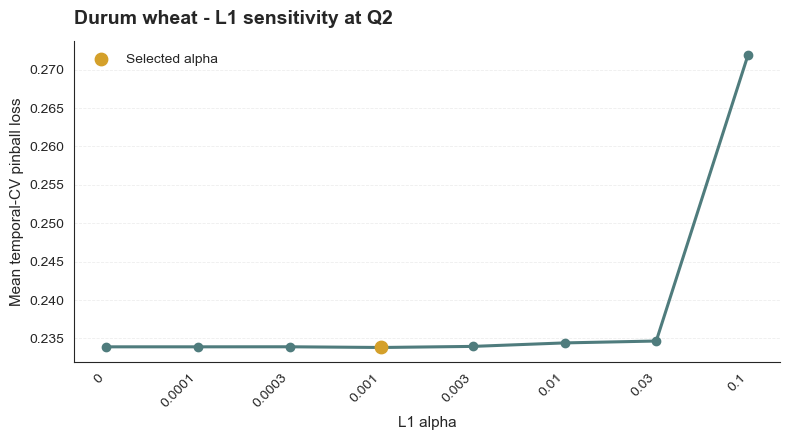

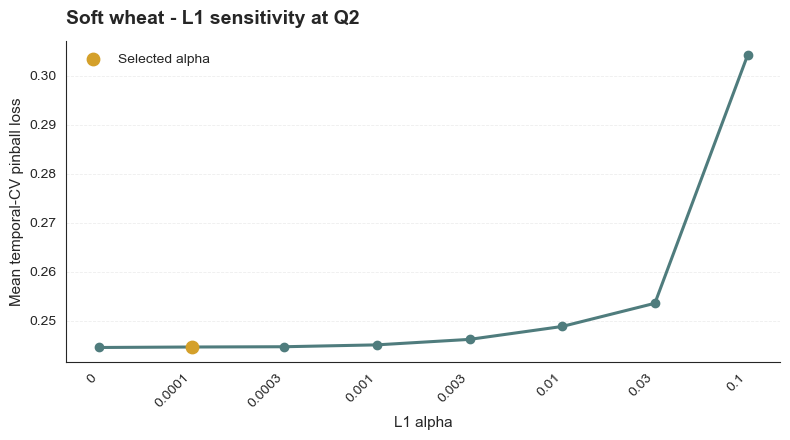

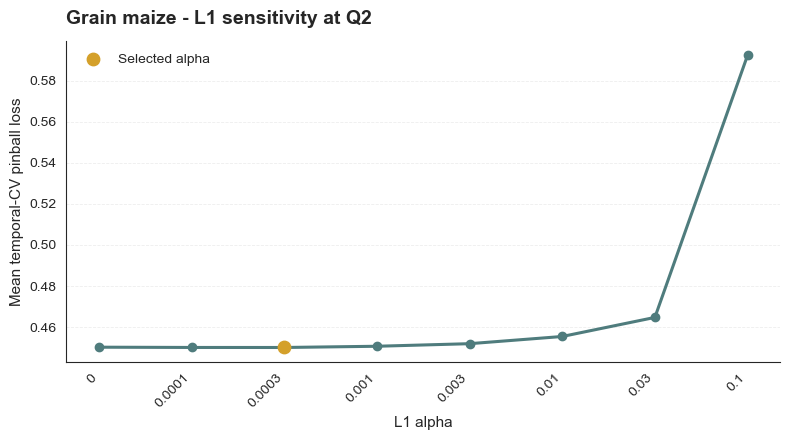

In [18]:
# Visualize the Q2 sensitivity to alpha using the same project style. Alpha is
# treated as a categorical axis so the unregularized value 0 can be shown next
# to the logarithmically spaced positive penalties.
set_plot_style()

alpha_labels = [f"{alpha:g}" for alpha in L1_ALPHAS]

for crop in CROPS:
    plot_data = (
        l1_search[
            l1_search["crop"] == crop
        ]
        .set_index("alpha")
        .reindex(L1_ALPHAS)
        .reset_index()
    )

    selected_alpha = L1_BEST_ALPHA[crop]
    selected_row = plot_data[
        plot_data["alpha"] == selected_alpha
    ].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        range(len(plot_data)),
        plot_data["CV Q2"],
        marker="o",
        linewidth=2.2,
        color=TEAL,
    )

    ax.scatter(
        alpha_labels.index(f"{selected_alpha:g}"),
        selected_row["CV Q2"],
        s=80,
        color=GOLD,
        zorder=3,
        label="Selected alpha",
    )

    ax.set_title(f"{crop} - L1 sensitivity at Q2", loc="left")
    ax.set_xlabel("L1 alpha")
    ax.set_ylabel("Mean temporal-CV pinball loss")
    ax.set_xticks(range(len(alpha_labels)))
    ax.set_xticklabels(alpha_labels, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend()

    fig.tight_layout()
    plt.show()

### Selected L1 models

The chosen `alpha` is now applied to Q1, Q2 and Q3 on the same SFS predictors. This keeps the tuning decision anchored to the primary Q2 objective while allowing the lower and upper conditional quantiles to be checked without a separate hyperparameter search.

The fitted full-development models are stored in `L1_MODELS` with explicit names so they can be reused later for the untouched benchmark without repeating the fit.

In [19]:
# Keep the final crop/quantile fits available for the later benchmark section.
L1_MODELS = {}
l1_results_rows = []

for crop in CROPS:
    crop_development = (
        development_data[
            development_data["crop_name"] == crop
        ]
        .copy()
    )

    features = SFS_SELECTED_FEATURES[crop]
    alpha = L1_BEST_ALPHA[crop]

    scores = evaluate_regularized_feature_set(
        crop_development,
        features,
        alpha,
        QUANTILES,
        CV_FOLDS,
    )

    l1_results_rows.append({
        "crop": crop,
        "model": "LinearQR-L1",
        "features": "SFS",
        "alpha": alpha,
        "n_features": len(features),
        **scores,
    })

    # Store one final model per quantile, fitted on all development years.
    for quantile_name, quantile in QUANTILES.items():
        model_name = f"{crop}__LinearQR_L1_SFS_{quantile_name}"

        model = make_regularized_linear_pipeline(
            quantile,
            alpha,
        )

        model.fit(
            crop_development[features],
            crop_development["yield"],
        )

        L1_MODELS[model_name] = model

l1_results = pd.DataFrame(l1_results_rows)

# Compare the selected regularized model with its unregularized SFS counterpart.
linear_l1_comparison = pd.concat([
    sfs_results.assign(alpha=0.0),
    l1_results,
], ignore_index=True)

display(
    linear_l1_comparison[
        [
            "crop",
            "model",
            "features",
            "alpha",
            "n_features",
            "Train Q1",
            "CV Q1",
            "Train Q2",
            "CV Q2",
            "Train Q3",
            "CV Q3",
        ]
    ]
    .set_index(["crop", "model", "features"])
)

,,,alpha,n_features,Train Q1,CV Q1,Train Q2,CV Q2,Train Q3,CV Q3
crop,model,features,,,,,,,,
Durum wheat,LinearQR,SFS,0,12,0.19815,0.203725,0.236968,0.233904,0.198888,0.200669
Soft wheat,LinearQR,SFS,0,18,0.206807,0.224383,0.24033,0.244496,0.196539,0.203132
Grain maize,LinearQR,SFS,0,25,0.406718,0.396601,0.474964,0.450262,0.403291,0.401842
Durum wheat,LinearQR-L1,SFS,0.001,12,0.198157,0.203656,0.236983,0.233818,0.1989,0.200717
Soft wheat,LinearQR-L1,SFS,0.0001,18,0.206807,0.224257,0.24033,0.244594,0.196541,0.203097
Grain maize,LinearQR-L1,SFS,0.0003,25,0.406754,0.396191,0.474973,0.450116,0.40331,0.400909


## Q2 screening with CatBoost

### Gradient boosting and CatBoost

Linear quantile regression requires the effect of the predictors to be represented through an additive linear function. Agricultural yield relationships, however, may contain **thresholds, nonlinear responses and interactions**. For example, the effect of precipitation may depend on temperature, crop phase or the level of water stress rather than remaining constant over the full predictor range.

Gradient-boosted decision trees provide a natural way to relax this assumption. Instead of fitting a single global equation, boosting constructs an ensemble of decision trees sequentially. Each new tree is added to reduce the remaining prediction error of the current ensemble.

**CatBoost** is a gradient-boosting implementation that supports regression and quantile objectives directly. Tree-based models can represent:

- nonlinear predictor-response relationships;
- threshold effects;
- interactions between variables;
- heterogeneous effects across different regions of the feature space.

They also do not require numerical feature standardization and can handle missing numerical values internally.

This additional flexibility comes with a corresponding risk of overfitting, especially when the number of available predictors is large relative to the number of observations. Early stopping is therefore used here as a minimal regularization mechanism: the optimal number of boosting iterations is identified using the most recent part of each training window, while the external temporal validation fold remains completely unseen.

Because **Q2 is the primary model-selection objective**, CatBoost is evaluated directly with a median quantile loss.
**No hyperparameter search is introduced**, due to a precise design reason: model development here follows a sequential budget logic, **tuning is an investment justified by a preliminary positive signal**, not a prerequisite for a fair first assessment. 
Moreover, **robust default behaviour is an explicit part of CatBoost's value proposition**, so an out-of-the-box configuration with temporal early stopping is a legitimate representation of the model family at this screening stage. The claims made in this section are consequently scoped to the default specification: they establish whether gradient boosting is promising enough on this dataset to warrant an effort in tuning.

Three feature representations are considered:

- `H`: the parsimonious historical predictor set;
- `SFS`: the crop-specific subset selected for linear Q2 regression;
- `Full`: the complete predictor pool, retained as a sensitivity experiment.

The `Full` specification is particularly informative for CatBoost because a feature that provides little linear incremental value may still contribute through nonlinear effects or interactions.

### Temporal evaluation

CatBoost is evaluated on the same three expanding temporal folds used by the linear models.

`H` and `SFS` are the primary specifications. `Full` remains a high-dimensional attempt.

For each fold, the stopping iteration is learned only from the fold's own training years. The model is then refitted on that complete training window before predicting the later validation block.

The final 1995-2015 CatBoost models follow the same rule and are stored for the later validation step. The reported iteration counts make the effect of early stopping visible without introducing a tuning grid.

In [20]:
catboost_q2_fold_rows = []
catboost_q2_rows = []
CATBOOST_Q2_MODELS = {}

for crop in CROPS:
    crop_data = development_data[
        development_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP),
        "SFS": native_feature_names(
            SFS_SELECTED_FEATURES[crop],
            NATIVE_FEATURE_MAP,
        ),
        "Full": native_feature_names(
            SFS_CANDIDATE_FEATURES,
            NATIVE_FEATURE_MAP,
        ),
    }

    for feature_label, features in feature_sets.items():
        fold_losses = []
        fold_iterations = []

        for fold_name, validation_start, validation_end in CV_FOLDS:
            train = crop_data[
                crop_data["harvest_year"] < validation_start
            ]
            validation = crop_data[
                crop_data["harvest_year"].between(
                    validation_start,
                    validation_end,
                )
            ]

            model, best_iterations = fit_catboost_q2(
                train,
                features,
                EARLY_STOPPING_YEARS,
                EARLY_STOPPING_ROUNDS,
            )

            loss = pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            )

            fold_losses.append(loss)
            fold_iterations.append(best_iterations)
            catboost_q2_fold_rows.append({
                "crop": crop,
                "features": feature_label,
                "fold": fold_name,
                "Q2 pinball": loss,
                "iterations": best_iterations,
            })

        final_model, final_iterations = fit_catboost_q2(
            crop_data,
            features,
            EARLY_STOPPING_YEARS,
            EARLY_STOPPING_ROUNDS,
        )

        train_q2 = pinball(
            crop_data["yield"],
            final_model.predict(crop_data[features]),
            QUANTILES["Q2"],
        )

        CATBOOST_Q2_MODELS[
            f"{crop}__CatBoostQ2_{feature_label}"
        ] = final_model

        catboost_q2_rows.append({
            "crop": crop,
            "model": "CatBoostQ2",
            "features": feature_label,
            "n_features": len(features),
            "Train Q2": train_q2,
            "CV Q2": np.mean(fold_losses),
            "Mean CV iterations": np.mean(fold_iterations),
            "Final iterations": final_iterations,
        })

catboost_q2_results = pd.DataFrame(catboost_q2_rows)
catboost_q2_fold_results = pd.DataFrame(
    catboost_q2_fold_rows
)

display(
    catboost_q2_results
    .set_index(["crop", "model", "features"])
)

n_features  Train Q2    CV Q2  Mean CV iterations  Final iterations
crop        model      features                                                                     
Durum wheat CatBoostQ2 H                  4  0.213079 0.235854             213.333               261
                       SFS               12  0.181012 0.240514             227.333               302
                       Full             196   0.16732 0.261152                 127               256
Soft wheat  CatBoostQ2 H                  4   0.23587 0.267872                 210               165
                       SFS               18  0.184562 0.262959             255.667               314
                       Full             196  0.163522 0.281811                 306               330
Grain maize CatBoostQ2 H                  4  0.457746 0.460483                 217               180
                       SFS               25  0.409055 0.460734             321.333               198
                       Full             196  0.389662 0.470954                 341               231

### Development comparison

The early-stopped CatBoost results are compared with the linear Q2 models evaluated on the same development folds.

The comparison remains deliberately limited to Q2 because this is the screening objective.

In [21]:
development_q2_comparison = pd.concat([
    baseline_results[["crop", "CV Q2"]].assign(
        model_label="Linear H"
    ),
    sfs_results[["crop", "CV Q2"]].assign(
        model_label="Linear SFS"
    ),
    l1_results[["crop", "CV Q2"]].assign(
        model_label="Linear L1 SFS"
    ),
    catboost_q2_results[["crop", "features", "CV Q2"]].assign(
        model_label=lambda x: "CatBoost " + x["features"]
    )[["crop", "model_label", "CV Q2"]],
], ignore_index=True)

display(
    development_q2_comparison
    .sort_values(["crop", "CV Q2"])
    .set_index(["crop", "model_label"])
)

CV Q2
crop        model_label           
Durum wheat Linear L1 SFS 0.233818
            Linear SFS    0.233904
            CatBoost H    0.235854
            CatBoost SFS  0.240514
            Linear H      0.241013
            CatBoost Full 0.261152
Grain maize Linear L1 SFS 0.450116
            Linear SFS    0.450262
            CatBoost H    0.460483
            CatBoost SFS  0.460734
            CatBoost Full 0.470954
            Linear H      0.473793
Soft wheat  Linear SFS    0.244496
            Linear L1 SFS 0.244594
            Linear H       0.25635
            CatBoost SFS  0.262959
            CatBoost H    0.267872
            CatBoost Full 0.281811

### CatBoost interpretation

This CatBoost setup improves several development scores relative to the earlier unrestricted fit, but it does not change the main model ranking.

- For **durum wheat**, `CatBoost H` becomes competitive with the linear models, but the best linear SFS specifications retain the lowest mean temporal-CV Q2. Adding the SFS or complete feature sets does not improve CatBoost further.

- For **grain maize**, early-stopped CatBoost narrows the gap, especially with the compact `H` specification, but both linear SFS models remain clearly stronger on mean temporal-CV Q2.

- For **soft wheat**, `CatBoost SFS` is the strongest CatBoost specification, yet its mean CV loss remains above both the selected linear model and the simpler `Linear H` reference.

The `Full` specification provides a consistent warning against unrestricted dimensionality in this dataset. It achieves substantially lower training loss but does not translate that additional fitting capacity into better temporal validation performance (and, with that many features, it was in fact expected to be faced with overfitting). 
Native missing-value handling and early stopping therefore make CatBoost a more credible nonlinear benchmark, but the development evidence still does not justify selecting it over the strongest linear candidates.

Native missing-value handling and early stopping therefore make CatBoost a more credible nonlinear benchmark. 
The development evidence nevertheless gives no indication that a default-configuration CatBoost improves on the strongest linear candidates for any crop, and therefore provides no preliminary signal that would justify allocating a tuning budget to this model.
(This does not exclude that a different configuration could perform better, but it just means that from what it has been possible to see preliminarly it has been determined as more advantageous to pursue a different approach).

## Validation set: 2016-2018

The 2016-2022 block is divided chronologically into:

- **2016-2018: validation set**, used for model comparison after the development work;
- **2019-2022: final test set**, which remains completely untouched.

The earlier temporal folds are the inner development validation used for SFS, regularization checks and model screening. The outer-validation period is the last dataset that may inform the model choice.

The 2019-2022 final test will only be used to evaluate the already chosen model, not to choose among candidates.

In [22]:
outer_validation_data = benchmark_data[
    benchmark_data["harvest_year"].between(2016, 2018)
].copy()

final_test_data = benchmark_data[
    benchmark_data["harvest_year"] >= 2019
].copy()

split_sizes = pd.concat([
    outer_validation_data.groupby("crop_name").size().rename("2016-2018 validation"),
    final_test_data.groupby("crop_name").size().rename("2019-2022 final test"),
], axis=1)

display(split_sizes)

,2016-2018 validation,2019-2022 final test
crop_name,,
Durum wheat,276,373
Grain maize,283,366
Soft wheat,286,361


### Outer-validation results

All Q2 models retained so far are evaluated on 2016-2018 after fitting only on the 1995-2015 development period.

For CatBoost, the stopping iteration is determined within 1995-2015 and the final model is refitted on the complete development period before predicting 2016-2018. The outer-validation observations are never used by early stopping.

The main CatBoost comparison remains `H` versus `SFS`; `Full` remains an additional sensitivity experiment. Lower pinball loss is better.

In [23]:
outer_rows = []
Q2_DEVELOPMENT_MODELS = {}

for crop in CROPS:
    train = development_data[
        development_data["crop_name"] == crop
    ].copy()

    validation = outer_validation_data[
        outer_validation_data["crop_name"] == crop
    ].copy()

    # Linear Q2 models.
    linear_specs = {
        "Linear H": (
            HISTORICAL_FEATURES,
            make_linear_pipeline(QUANTILES["Q2"]),
        ),
        "Linear SFS": (
            SFS_SELECTED_FEATURES[crop],
            make_linear_pipeline(QUANTILES["Q2"]),
        ),
        "Linear L1 SFS": (
            SFS_SELECTED_FEATURES[crop],
            make_regularized_linear_pipeline(
                QUANTILES["Q2"],
                L1_BEST_ALPHA[crop],
            ),
        ),
    }

    for model_label, (features, model) in linear_specs.items():
        model.fit(train[features], train["yield"])
        Q2_DEVELOPMENT_MODELS[f"{crop}__{model_label}"] = model

        outer_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Outer validation Q2": pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            ),
        })

    # CatBoost models were already fitted on the complete development period.
    catboost_features = {
        "CatBoost H": ("H", native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP)),
        "CatBoost SFS": ("SFS", native_feature_names(SFS_SELECTED_FEATURES[crop], NATIVE_FEATURE_MAP)),
        "CatBoost Full": ("Full", native_feature_names(SFS_CANDIDATE_FEATURES, NATIVE_FEATURE_MAP)),
    }

    for model_label, (feature_label, features) in catboost_features.items():
        model = CATBOOST_Q2_MODELS[
            f"{crop}__CatBoostQ2_{feature_label}"
        ]
        Q2_DEVELOPMENT_MODELS[f"{crop}__{model_label}"] = model

        outer_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Outer validation Q2": pinball(
                validation["yield"],
                model.predict(validation[features]),
                QUANTILES["Q2"],
            ),
        })

outer_validation_results = pd.DataFrame(outer_rows)

outer_comparison = (
    development_q2_comparison
    .merge(
        outer_validation_results,
        on=["crop", "model_label"],
        how="left",
    )
)

display(
    outer_comparison
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

CV Q2  Outer validation Q2
crop        model_label                                
Durum wheat Linear H      0.241013             0.195533
            Linear L1 SFS 0.233818             0.198056
            Linear SFS    0.233904             0.198126
            CatBoost H    0.235854             0.204929
            CatBoost SFS  0.240514             0.210005
            CatBoost Full 0.261152              0.22119
Grain maize Linear L1 SFS 0.450116             0.425793
            Linear SFS    0.450262             0.426646
            Linear H      0.473793             0.429603
            CatBoost H    0.460483             0.438843
            CatBoost SFS  0.460734             0.441446
            CatBoost Full 0.470954             0.445858
Soft wheat  CatBoost SFS  0.262959             0.228013
            Linear H       0.25635             0.228368
            Linear L1 SFS 0.244594              0.23157
            Linear SFS    0.244496             0.231784
            CatBoost Full 0.281811              0.23245
            CatBoost H    0.267872             0.233262

### Visual comparison of the performances on the validation period

The barplots show only the 2016-2018 outer-validation loss, keeping this evidence visually separate from the inner development CV.

Models are ordered by Q2 pinball loss within each crop. The CatBoost `Full` specification remains a sensitivity experiment rather than a preferred feature strategy by construction.

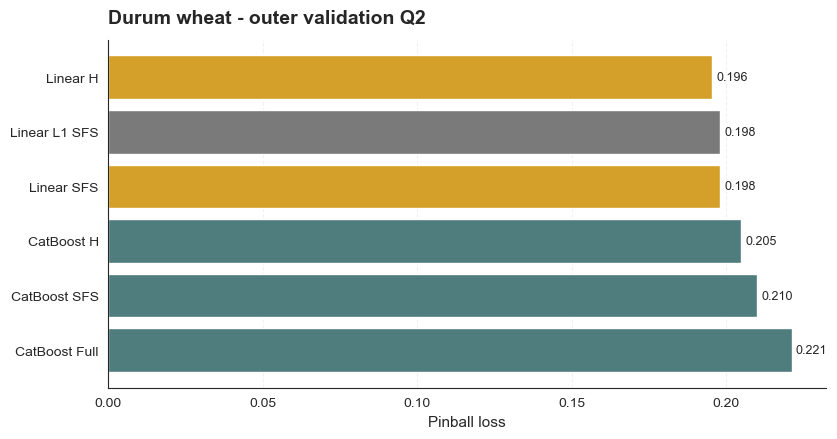

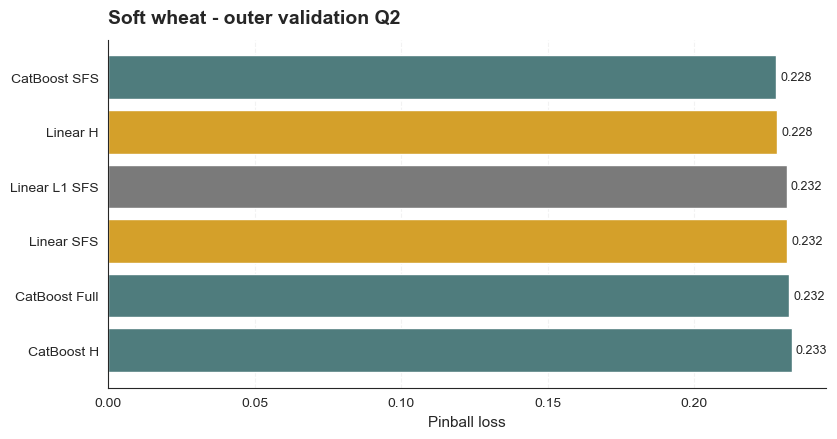

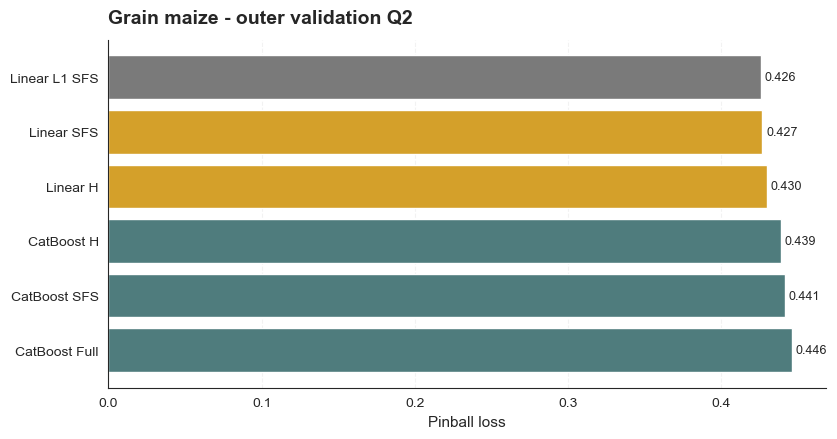

In [24]:
set_plot_style()

for crop in CROPS:
    plot_data = (
        outer_validation_results[
            outer_validation_results["crop"] == crop
        ]
        .sort_values("Outer validation Q2", ascending=True)
    )

    colors = [
        (
            GRAY_MED
            if label == "Linear L1 SFS"
            else TEAL
            if label.startswith("CatBoost")
            else GOLD
        )
        for label in plot_data["model_label"]
    ]

    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    bars = ax.barh(
        plot_data["model_label"],
        plot_data["Outer validation Q2"],
        color=colors,
    )

    ax.invert_yaxis()
    ax.set_title(f"{crop} - outer validation Q2")
    ax.set_xlabel("Pinball loss")
    ax.set_ylabel("")
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )
    ax.set_axisbelow(True)

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()


### Outer-validation interpretation

The 2016-2018 period changes the interpretation of the feature-selection results more than it changes the ranking between model families.

- For **durum wheat**, the simple `Linear H` specification achieves the lowest outer-validation Q2 loss. The larger SFS models, despite their development-CV advantage, no longer improve the median forecast. CatBoost also remains behind the linear alternatives.

- For **grain maize**, the two linear SFS specifications remain the strongest candidates. Their advantage over `Linear H` is small on this later period but still present, while none of the CatBoost specifications improves on them.

- For **soft wheat**, the ordering changes more substantially. `Linear H` outperforms both linear SFS models, while `CatBoost SFS` reaches an almost identical loss and is marginally lower. The difference between `CatBoost SFS` and `Linear H` is extremely small, however, and CatBoost remains weaker across the development folds. This should therefore be treated as a late-period near-tie rather than evidence of a clear CatBoost advantage.

Overall, **the outer validation weakens the case for automatically retaining climate variables simply because they were selected during development**. Their predictive contribution is crop- and period-dependent, making temporal robustness more important than the best score obtained in any single development stage.

## Conclusions after conventional models

The work so far compare two conventional modelling families with substantially different inductive biases: linear quantile regression and gradient-boosted decision trees.

The linear models provide the strongest overall development evidence. Climate-enhanced SFS specifications improve the historical baseline consistently across the development folds, although the 2016-2018 outer validation shows that this advantage does not transfer equally to every crop. In particular, the simpler historical specification remains highly competitive outside the feature-selection period.

CatBoost introduces non-linearity, thresholds and interactions without requiring an explicit functional form. Temporal early stopping and native missing-value handling make it a substantially more robust challenger than the initial unrestricted specification. The updated model becomes competitive in several cases, including a near-tie with `Linear H` for soft wheat on 2016-2018, but it still does not show a consistent advantage over the strongest linear references across the development folds.

No CatBoost specification reaches the strongest linear references on the development folds, so there is no preliminary signal that would make a tuning investment in this family worthwhile at this stage. The next experiment therefore reallocates that budget to a model family based on a different learning paradigm, **tabular foundation models**, rather than to a deeper search within gradient boosting.

This additional comparison is particularly relevant to be able to verify if a model that transfers knowledge learned across many previous tabular problems can exploit the available historical and climate information more effectively than models trained exclusively on the current crop dataset.

## **Tabular foundation models and TabPFN**

### Tabular foundation models

Most supervised machine-learning algorithms are **task-specific**. A linear model, a random forest or a gradient-boosting model starts with a predefined learning algorithm and estimates its parameters from the training observations of the current dataset.

Foundation models introduce a different paradigm. Instead of learning only from the target dataset, a model is first **pretrained across a large collection of tasks**. The objective of pretraining is to acquire reusable knowledge that can later be transferred to previously unseen problems.

This paradigm has been highly successful in domains such as language and images, where very large pretrained models can adapt to new tasks with limited additional information. Applying the same idea to tabular data is more difficult because tables do not share a universal structure: different datasets can contain completely different features, units, distributions and relationships between predictors and targets.

**Tabular foundation models** attempt to overcome this problem by learning reusable strategies for prediction across many different tabular tasks rather than memorizing one fixed feature representation.

Conceptually, this changes the source of the model's inductive bias:

- a linear model assumes a predefined functional form;
- gradient boosting learns flexible rules from the current dataset;
- a tabular foundation model can additionally exploit knowledge acquired during pretraining across other prediction problems.

The target dataset is therefore no longer the model's only source of statistical information.

### Prior-Data Fitted Networks

TabPFN belongs to the family of **Prior-Data Fitted Networks (PFNs)**.

Instead of being pretrained on a fixed collection of real-world datasets, a PFN is trained on a very large distribution of **synthetically generated prediction problems**. These artificial datasets are sampled from a prior designed to represent many possible relationships between predictors and targets, including nonlinearities, interactions, noise and different data-generating structures.

During pretraining, the model repeatedly observes a dataset divided into labelled and unlabelled examples and learns to predict the missing targets. Across millions of such tasks, the network effectively learns not only representations of data but a **general prediction procedure**.

The resulting model can be interpreted as learning an approximation to Bayesian inference under the distribution of synthetic tasks used during pretraining. Given a new training dataset, it uses the observed examples to infer which kinds of relationships are plausible and forms predictions for new observations.

This is fundamentally different from fitting CatBoost or linear regression: the expensive learning of the general prediction strategy has already occurred during pretraining.

### In-context learning in TabPFN

At prediction time, TabPFN uses **in-context learning**.

In conventional supervised learning,

\[
\text{training data}
\rightarrow
\text{parameter optimization}
\rightarrow
\text{fitted model}
\rightarrow
\text{prediction}.
\]

TabPFN instead receives the labelled training observations as part of its prediction context:

\[
(X_{\text{train}}, y_{\text{train}}, X_{\text{test}})
\rightarrow
\text{pretrained TabPFN}
\rightarrow
p(y_{\text{test}} \mid X_{\text{train}}, y_{\text{train}}, X_{\text{test}}).
\]

The model therefore adapts to the new dataset through its **input context**, rather than by learning a completely new set of neural-network parameters from scratch.

The familiar `.fit()` interface should consequently not be interpreted in exactly the same way as fitting the previous estimators. In the basic TabPFN workflow, the training observations become the context on which the pretrained model conditions its predictions.

For regression, TabPFN can return a predictive distribution rather than only a single point estimate. This is especially useful in the present project because Q1, Q2 and Q3 can be extracted from the same predicted conditional distribution instead of fitting three completely independent regression models.

### Why TabPFN is relevant to this project

The characteristics of the present dataset make TabPFN a particularly relevant option.

Each crop provides only a few thousand annual province-level observations, while the complete representation contains a comparatively large number of historical and phase-level climate predictors. Many of these variables are correlated and their relationship with yield may involve interactions, thresholds or other nonlinear structures.

This creates a difficult regime for conventional modelling:

- simple linear models may underrepresent complex relationships;
- highly flexible models can overfit because task-specific training data are limited;
- aggressive feature selection can discard variables whose value appears only through nonlinear interactions.

A pretrained tabular model offers a different trade-off. TabPFN brings an external inductive bias learned from many previous synthetic prediction problems while still conditioning directly on the observations available for each crop.

The comparison of `H`, `SFS` and `Full` is therefore more than a feature-count experiment. It also tests whether the feature subset identified for a linear model remains appropriate for a model whose learned prediction strategy is fundamentally different.

At the same time, pretraining does not guarantee temporal generalization. The synthetic prior used to train TabPFN is not specific to Italian agriculture, and relationships in the real data may change across time. TabPFN is therefore evaluated with exactly the same chronological logic used for the conventional models.

### Experimental setup

The previous three feature definitions are preserved:

- `H`, containing the historical predictors;
- `SFS`, containing the crop-specific subset selected by linear Q2 regression;
- `Full`, containing the complete candidate predictor pool.

Historical missing values are passed natively to TabPFN instead of being replaced by the earlier zero-imputed representation. The SFS procedure itself is not repeated: selected historical variables are simply mapped back to their raw counterparts. This preserves the completed feature-selection experiment while allowing TabPFN to use its native treatment of missing information.

No task-specific TabPFN tuning is introduced. `random_state=0` is fixed and thinking mode remains disabled.

Q1, Q2 and Q3 are obtained from the predictive distribution returned by the same TabPFN regressor, with Q2 retained as the primary model-comparison metric.

**Reference:** Hollmann, N. et al. (2025). *Accurate predictions on small data with a tabular foundation model*. Nature, 637, 319-326.

In [25]:
load_dotenv()

TABPFN_TOKEN = os.environ["TABPFN_TOKEN"]
tabpfn_client.set_access_token(TABPFN_TOKEN)

In [26]:
tabpfn_rows = []
TABPFN_MODELS = {}

for crop in CROPS:
    train = development_data[
        development_data["crop_name"] == crop
    ].copy()

    validation = outer_validation_data[
        outer_validation_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP),
        "SFS": native_feature_names(SFS_SELECTED_FEATURES[crop], NATIVE_FEATURE_MAP),
        "Full": native_feature_names(SFS_CANDIDATE_FEATURES, NATIVE_FEATURE_MAP),
    }

    for feature_label, features in feature_sets.items():
        model = TabPFNRegressor(
            random_state=0,
            thinking_mode=False,
        )

        model.fit(
            train[features],
            train["yield"],
        )

        predictions = model.predict(
            validation[features],
            output_type="quantiles",
            quantiles=[0.25, 0.50, 0.75],
        )

        q1, q2, q3 = predictions

        TABPFN_MODELS[
            f"{crop}__TabPFN_{feature_label}"
        ] = model

        tabpfn_rows.append({
            "crop": crop,
            "model_label": f"TabPFN {feature_label}",
            "Outer validation Q1": pinball(
                validation["yield"], q1, 0.25
            ),
            "Outer validation Q2": pinball(
                validation["yield"], q2, 0.50
            ),
            "Outer validation Q3": pinball(
                validation["yield"], q3, 0.75
            ),
        })

tabpfn_results = pd.DataFrame(tabpfn_rows)

display(
    tabpfn_results
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

00:00 Fitting... \

Train set already exists, skipping upload.


00:04 Fitting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:01 Predicting... Done!
00:00 Fitting... \

...

Train set already exists, skipping upload.


00:03 Fitting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:03 Predicting... Done!


Outer validation Q1  Outer validation Q2  Outer validation Q3
crop        model_label                                                               
Durum wheat TabPFN H                0.170506             0.198393             0.170128
            TabPFN SFS               0.17123             0.200921             0.172907
            TabPFN Full             0.171974             0.201195             0.163975
Grain maize TabPFN Full              0.33909             0.406358             0.344969
            TabPFN SFS              0.343955             0.418836             0.367799
            TabPFN H                0.377458             0.424602             0.364914
Soft wheat  TabPFN Full             0.177191             0.210746             0.178223
            TabPFN H                0.185168             0.220857             0.186207
            TabPFN SFS              0.180598             0.222737              0.18999

Outer validation Q2
crop        model_label                       
Durum wheat Linear H                  0.195533
            TabPFN H                  0.198393
            TabPFN SFS                0.200921
            TabPFN Full               0.201195
Grain maize TabPFN Full               0.406358
            TabPFN SFS                0.418836
            TabPFN H                  0.424602
            Linear L1 SFS             0.425793
Soft wheat  TabPFN Full               0.210746
            TabPFN H                  0.220857
            TabPFN SFS                0.222737
            Linear H                  0.228368

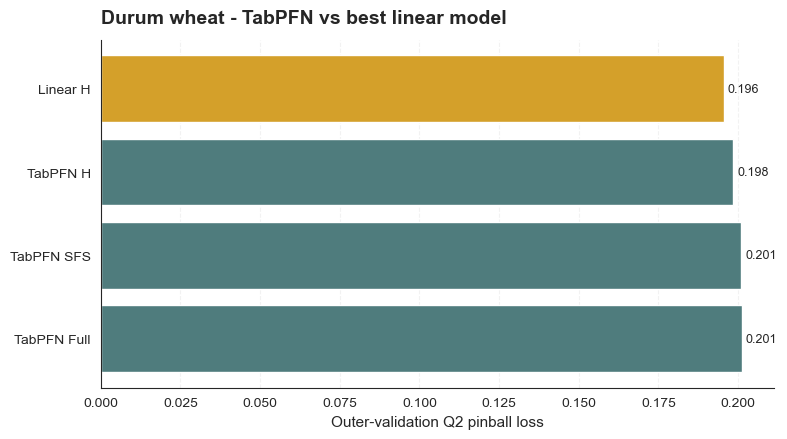

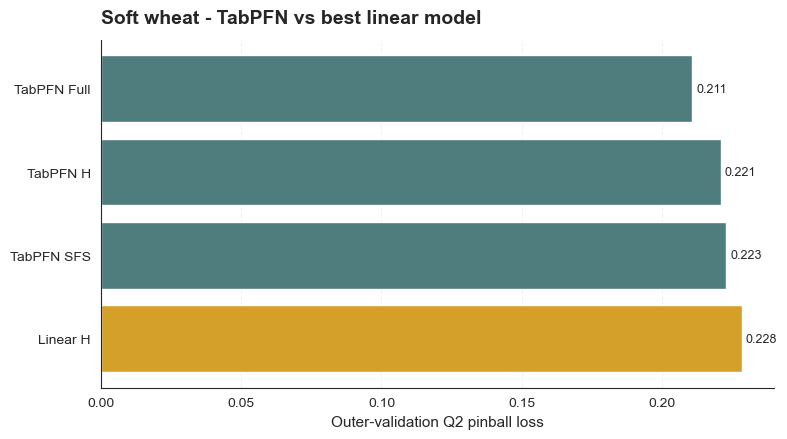

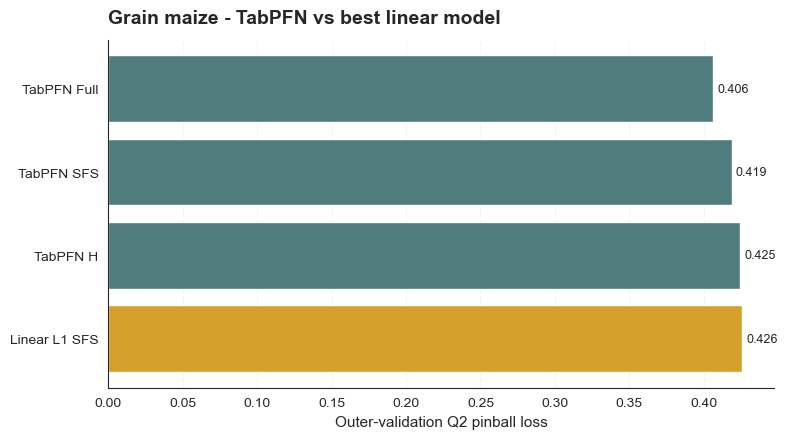

In [27]:
# Select the best linear model for each crop.
linear_winners = (
    outer_validation_results[
        outer_validation_results["model_label"].str.startswith("Linear")
    ]
    .sort_values(["crop", "Outer validation Q2"])
    .groupby("crop", as_index=False)
    .first()
)

# Add TabPFN results.
tabpfn_comparison = pd.concat([
    linear_winners,
    tabpfn_results[
        ["crop", "model_label", "Outer validation Q2"]
    ],
], ignore_index=True)

display(
    tabpfn_comparison
    .sort_values(["crop", "Outer validation Q2"])
    .set_index(["crop", "model_label"])
)

# Visual comparison.
set_plot_style()

for crop in CROPS:
    plot_data = (
        tabpfn_comparison[
            tabpfn_comparison["crop"] == crop
        ]
        .sort_values("Outer validation Q2")
    )

    colors = [
        GOLD if label.startswith("Linear") else TEAL
        for label in plot_data["model_label"]
    ]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    bars = ax.barh(
        plot_data["model_label"],
        plot_data["Outer validation Q2"],
        color=colors,
    )

    ax.invert_yaxis()
    ax.set_title(
        f"{crop} - TabPFN vs best linear model",
        loc="left",
    )
    ax.set_xlabel("Outer-validation Q2 pinball loss")
    ax.set_ylabel("")
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )
    ax.set_axisbelow(True)

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

### Validation set comparison

The 2016-2018 results immediately separate the three crops.

- For **durum wheat**, no TabPFN specification improves on `Linear H`. The differences are relatively small, but the additional model complexity is not accompanied by a predictive gain.

- For **grain maize**, all three TabPFN specifications improve on the strongest linear reference on this period, with `TabPFN Full` providing the lowest Q2 loss. This shows that predictors which were not retained by linear SFS can still contain information usable by a model with a different inductive bias.

- For **soft wheat**, TabPFN also improves clearly on the linear reference, and `TabPFN Full` again produces the best 2016-2018 result. Native handling of the historical missing values particularly strengthens this specification relative to the earlier imputed experiment.

These results make TabPFN a genuine challenger for grain maize and soft wheat. They are not sufficient, however, to establish `Full` as the preferred specification: the outer validation represents only one temporal window, and the complete feature pool must still demonstrate that its advantage is not specific to this period.

In [28]:
TABPFN_BACKTEST_CROPS = [
    "Grain maize",
    "Soft wheat",
]

tabpfn_fold_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    crop_data = development_data[
        development_data["crop_name"] == crop
    ].copy()

    feature_sets = {
        "H": native_feature_names(HISTORICAL_FEATURES, NATIVE_FEATURE_MAP),
        "Full": native_feature_names(SFS_CANDIDATE_FEATURES, NATIVE_FEATURE_MAP),
    }

    for feature_label, features in feature_sets.items():
        for fold_name, validation_start, validation_end in CV_FOLDS:
            train = crop_data[
                crop_data["harvest_year"] < validation_start
            ]

            validation = crop_data[
                crop_data["harvest_year"].between(
                    validation_start,
                    validation_end,
                )
            ]

            model = TabPFNRegressor(
                random_state=0,
                thinking_mode=False,
            )

            model.fit(
                train[features],
                train["yield"],
            )

            predictions = model.predict(
                validation[features],
                output_type="quantiles",
                quantiles=[0.25, 0.50, 0.75],
            )

            q1, q2, q3 = predictions

            tabpfn_fold_rows.append({
                "crop": crop,
                "fold": fold_name,
                "model_label": f"TabPFN {feature_label}",
                "Q1": pinball(
                    validation["yield"],
                    q1,
                    0.25,
                ),
                "Q2": pinball(
                    validation["yield"],
                    q2,
                    0.50,
                ),
                "Q3": pinball(
                    validation["yield"],
                    q3,
                    0.75,
                ),
            })

tabpfn_fold_results = pd.DataFrame(
    tabpfn_fold_rows
)

display(
    tabpfn_fold_results
    .sort_values(["crop", "fold", "Q2"])
    .set_index(["crop", "fold", "model_label"])
)

00:00 Fitting... \

Train set already exists, skipping upload.


00:04 Fitting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:01 Predicting... Done!
00:00 Fitting... -

...

Train set already exists, skipping upload.


00:02 Fitting... Done!
00:00 Predicting... \

Test set already exists, skipping upload.


00:02 Predicting... Done!


Q1       Q2       Q3
crop        fold      model_label                           
Grain maize 2007-2009 TabPFN H    0.341835 0.385747   0.3117
                      TabPFN Full 0.359113 0.400393 0.329177
            2010-2012 TabPFN H    0.437337 0.453309 0.360229
                      TabPFN Full 0.434846  0.47029 0.385661
            2013-2015 TabPFN H    0.384073 0.488969 0.457418
                      TabPFN Full 0.394318 0.504787 0.458611
Soft wheat  2007-2009 TabPFN H    0.217422  0.24747 0.193771
                      TabPFN Full 0.218077 0.248069  0.18928
            2010-2012 TabPFN Full 0.262866 0.293578 0.228765
                      TabPFN H     0.26243 0.296852  0.23455
            2013-2015 TabPFN H    0.220189 0.244423  0.19574
                      TabPFN Full 0.221084 0.262397 0.203342

In [29]:
linear_fold_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    crop_data = development_data[
        development_data["crop_name"] == crop
    ].copy()

    if crop == "Grain maize":
        model_label = "Linear L1 SFS"
        features = SFS_SELECTED_FEATURES[crop]
    else:
        model_label = "Linear H"
        features = HISTORICAL_FEATURES

    for fold_name, validation_start, validation_end in CV_FOLDS:
        train = crop_data[
            crop_data["harvest_year"] < validation_start
        ]

        validation = crop_data[
            crop_data["harvest_year"].between(
                validation_start,
                validation_end,
            )
        ]

        if crop == "Grain maize":
            model = make_regularized_linear_pipeline(
                QUANTILES["Q2"],
                L1_BEST_ALPHA[crop],
            )
        else:
            model = make_linear_pipeline(
                QUANTILES["Q2"]
            )

        model.fit(
            train[features],
            train["yield"],
        )

        prediction = model.predict(
            validation[features]
        )

        linear_fold_rows.append({
            "crop": crop,
            "fold": fold_name,
            "model_label": model_label,
            "Q2": pinball(
                validation["yield"],
                prediction,
                QUANTILES["Q2"],
            ),
        })

linear_fold_results = pd.DataFrame(
    linear_fold_rows
)

display(
    linear_fold_results
    .set_index(["crop", "fold", "model_label"])
)

Q2
crop        fold      model_label           
Grain maize 2007-2009 Linear L1 SFS 0.373792
            2010-2012 Linear L1 SFS 0.456368
            2013-2015 Linear L1 SFS 0.520189
Soft wheat  2007-2009 Linear H      0.241806
            2010-2012 Linear H      0.299519
            2013-2015 Linear H      0.227726

In [30]:
comparison_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    if crop == "Grain maize":
        linear_label = "Linear L1 SFS"
    else:
        linear_label = "Linear H"

    # Development folds.
    for fold_name, _, _ in CV_FOLDS:
        linear_q2 = linear_fold_results[
            (linear_fold_results["crop"] == crop)
            & (linear_fold_results["fold"] == fold_name)
        ]["Q2"].iloc[0]

        tabpfn_h_q2 = tabpfn_fold_results[
            (tabpfn_fold_results["crop"] == crop)
            & (tabpfn_fold_results["fold"] == fold_name)
            & (tabpfn_fold_results["model_label"] == "TabPFN H")
        ]["Q2"].iloc[0]

        tabpfn_full_q2 = tabpfn_fold_results[
            (tabpfn_fold_results["crop"] == crop)
            & (tabpfn_fold_results["fold"] == fold_name)
            & (tabpfn_fold_results["model_label"] == "TabPFN Full")
        ]["Q2"].iloc[0]

        comparison_rows.append({
            "crop": crop,
            "period": fold_name,
            linear_label: linear_q2,
            "TabPFN H": tabpfn_h_q2,
            "TabPFN Full": tabpfn_full_q2,
        })

    # Outer validation.
    linear_q2 = outer_validation_results[
        (outer_validation_results["crop"] == crop)
        & (outer_validation_results["model_label"] == linear_label)
    ]["Outer validation Q2"].iloc[0]

    tabpfn_h_q2 = tabpfn_results[
        (tabpfn_results["crop"] == crop)
        & (tabpfn_results["model_label"] == "TabPFN H")
    ]["Outer validation Q2"].iloc[0]

    tabpfn_full_q2 = tabpfn_results[
        (tabpfn_results["crop"] == crop)
        & (tabpfn_results["model_label"] == "TabPFN Full")
    ]["Outer validation Q2"].iloc[0]

    comparison_rows.append({
        "crop": crop,
        "period": "2016-2018 outer",
        linear_label: linear_q2,
        "TabPFN H": tabpfn_h_q2,
        "TabPFN Full": tabpfn_full_q2,
    })

tabpfn_temporal_comparison = pd.DataFrame(
    comparison_rows
)

display(
    tabpfn_temporal_comparison
    .set_index(["crop", "period"])
)

# Summarize the four available validation periods without declaring a winner.
summary_rows = []

for crop in TABPFN_BACKTEST_CROPS:
    crop_comparison = tabpfn_temporal_comparison[
        tabpfn_temporal_comparison["crop"] == crop
    ].copy()

    linear_label = (
        "Linear L1 SFS"
        if crop == "Grain maize"
        else "Linear H"
    )

    model_labels = [
        linear_label,
        "TabPFN H",
        "TabPFN Full",
    ]

    period_best = crop_comparison[model_labels].min(axis=1)

    for model_label in model_labels:
        values = crop_comparison[model_label]
        summary_rows.append({
            "crop": crop,
            "model_label": model_label,
            "Mean Q2": values.mean(),
            "Std Q2": values.std(ddof=0),
            "Best-period count": int(
                np.isclose(values, period_best).sum()
            ),
        })

tabpfn_temporal_summary = pd.DataFrame(summary_rows)

display(
    tabpfn_temporal_summary
    .sort_values(["crop", "Mean Q2"])
    .set_index(["crop", "model_label"])
)

Linear L1 SFS  TabPFN H  TabPFN Full  Linear H
crop        period                                                         
Grain maize 2007-2009             0.373792  0.385747     0.400393       NaN
            2010-2012             0.456368  0.453309      0.47029       NaN
            2013-2015             0.520189  0.488969     0.504787       NaN
            2016-2018 outer       0.425793  0.424602     0.406358       NaN
Soft wheat  2007-2009                  NaN   0.24747     0.248069  0.241806
            2010-2012                  NaN  0.296852     0.293578  0.299519
            2013-2015                  NaN  0.244423     0.262397  0.227726
            2016-2018 outer            NaN  0.220857     0.210746  0.228368

Mean Q2    Std Q2  Best-period count
crop        model_label                                        
Grain maize TabPFN H      0.438156 0.0378879                  2
            Linear L1 SFS 0.444035 0.0529583                  1
            TabPFN Full   0.445457 0.0438641                  1
Soft wheat  Linear H      0.249355 0.0295029                  2
            TabPFN H        0.2524 0.0276535                  0
            TabPFN Full   0.253697 0.0297599                  2

### Temporal backtest of the TabPFN finalists

The validation comparison is informative but covers only one later period. The temporal backtest therefore asks whether the strongest TabPFN configurations also remain competitive on the three earlier temporal folds.

To limit additional API usage, the backtest is restricted to grain maize and soft wheat, where TabPFN produced a meaningful outer-validation improvement. `TabPFN H` is retained to isolate the contribution of the model class with a parsimonious information set, while `TabPFN Full` tests whether the complete feature pool provides additional nonlinear signal.

A conventional in-sample training loss is not reported for TabPFN because the training observations form its prediction context. The comparable evidence is therefore the sequence of temporally out-of-sample losses.

The earlier development folds should be interpreted as temporal stability diagnostics rather than additional independent test sets, since they were already involved in the preceding model-development process. 

(The 2019-2022 final test remains completely untouched.)

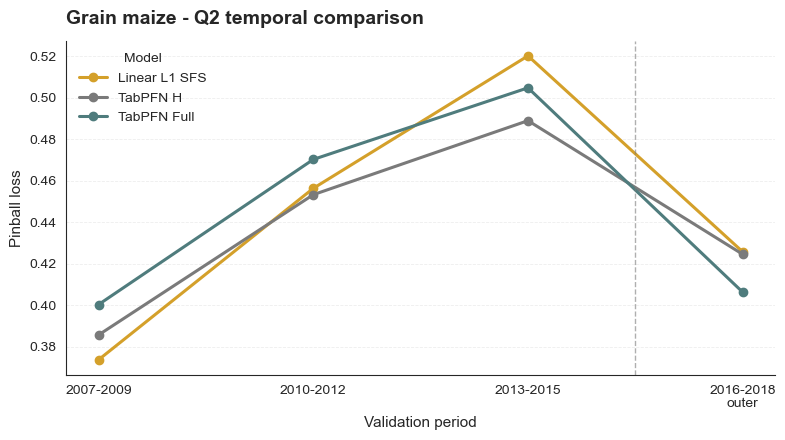

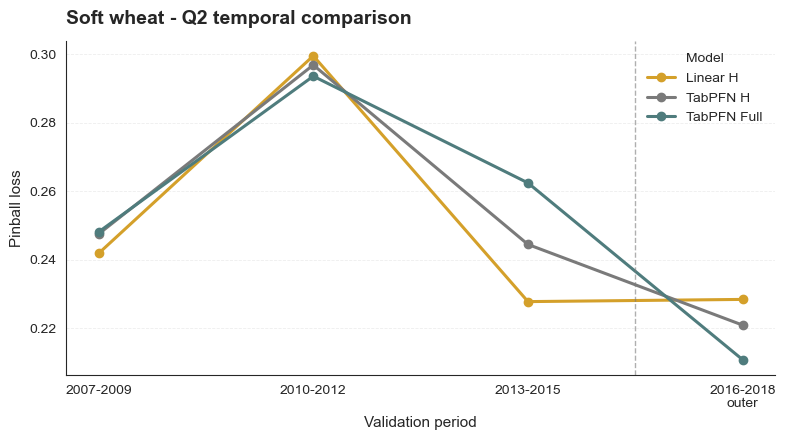

In [31]:
set_plot_style()

for crop in TABPFN_BACKTEST_CROPS:
    plot_data = (
        tabpfn_temporal_comparison[
            tabpfn_temporal_comparison["crop"] == crop
        ]
        .set_index("period")
        .drop(columns="crop")
    )

    linear_label = (
        "Linear L1 SFS"
        if crop == "Grain maize"
        else "Linear H"
    )

    x = range(len(plot_data))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(
        x,
        plot_data[linear_label],
        marker="o",
        linewidth=2.2,
        color=GOLD,
        label=linear_label,
    )

    ax.plot(
        x,
        plot_data["TabPFN H"],
        marker="o",
        linewidth=2.2,
        color=GRAY_MED,
        label="TabPFN H",
    )

    ax.plot(
        x,
        plot_data["TabPFN Full"],
        marker="o",
        linewidth=2.2,
        color=TEAL,
        label="TabPFN Full",
    )

    ax.axvline(
        2.5,
        color=GRAY_MED,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_title(
        f"{crop} - Q2 temporal comparison",
        loc="left",
    )
    ax.set_xlabel("Validation period")
    ax.set_ylabel("Pinball loss")

    ax.set_xticks(x)
    ax.set_xticklabels([
        "2007-2009",
        "2010-2012",
        "2013-2015",
        "2016-2018\nouter",
    ])

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35,
    )

    ax.legend(title="Model")

    fig.tight_layout()
    plt.show()

### Temporal robustness interpretation

For **grain maize**, `TabPFN H` provides the strongest overall temporal profile. Its mean Q2 loss across the four available validation windows is 0.4382, compared with 0.4440 for `Linear L1 SFS` and 0.4455 for `TabPFN Full`. It also has the lowest temporal variability and is best in two of the four periods. `TabPFN Full` produces the strongest result in 2016-2018, but this late-period advantage is not reproduced consistently in the earlier windows.

The maize result is therefore important for two reasons. First, TabPFN can improve on the strongest linear specification without requiring the complete feature set. Second, the excellent recent performance of `Full` does not by itself imply that a larger representation generalizes better through time.

For **soft wheat**, the evidence remains genuinely mixed. `Linear H` has the lowest mean loss across the four periods and is best in two of them. `TabPFN Full` also wins two periods, including a substantial advantage in 2016-2018, but its overall mean remains slightly higher. `TabPFN H` has the lowest temporal variability, although it is not the best model in any individual period.

The native-NaN experiment therefore strengthens the case for nonlinear modelling in soft wheat without resolving the final choice. In particular, the strong recent performance of `TabPFN Full` has to be balanced against the greater parsimony and better average temporal performance of `Linear H`.

## Model selection - TO BE CONTINUED

The experiments now provide enough evidence to narrow the candidate set, but the final crop-specific model choices is still open.

- For **durum wheat**, the evidence is already strongly concentrated around the parsimonious `Linear H` model. The SFS advantage observed during development does not survive the 2016-2018 outer validation, CatBoost remains weaker, and no TabPFN specification improves the primary Q2 score.

- For **grain maize**, the main comparison is between the strong linear SFS reference and TabPFN. Across the available temporal windows, `TabPFN H` currently offers the best combination of mean Q2 loss and temporal stability, while `TabPFN Full` achieves the best score in the most recent validation period. This distinction separates robustness across time from peak performance on a single period.

- For **soft wheat**, the evidence does not yet imply an equally clear ranking. `Linear H` has the best mean Q2 loss across the available periods, whereas `TabPFN Full` wins two periods and achieves a substantially lower loss in 2016-2018. The very small outer-validation advantage of `CatBoost SFS` over `Linear H` is not supported by its weaker development performance and therefore does not currently provide equally strong evidence for CatBoost.

The final selection rule must be fixed **before** evaluating 2019-2022.